# Attack-LLM-Judge — analysis notebook

Single source of truth for the clarity / informativeness analyses on the 714-paragraph evaluation set. Read-only against `data/paragraphs.db`.

**Judges (attack panel):** `judge_gemma9b`, `judge_llama8b`, `judge_qwen95b`.

**Methods (shared 714 human-written source paragraphs):**
- `original` — unrewritten human paragraph (baseline).
- `naive`, `lit_informed_tight`, `rubric_aware` — feedback-free single rewrite per paragraph.
- `bon_panel` — best-of-16 selection using two in-panel judges; run once per leave-one-out fold.

**Fold → judge-panel assignment** (from `attack_rewrites.judge_panel_json`):

| fold | in-panel (selectors) | held-out |
|---|---|---|
| 1 | qwen95b, llama8b | gemma9b |
| 2 | qwen95b, gemma9b | llama8b |
| 3 | llama8b, gemma9b | qwen95b |

**Gaps currently blocking full analysis** — see `DATA_REQUIREMENTS.md`. In short: GRPO-trained rewrites are not yet persisted to the DB on the 714-paragraph eval set, and LLM-generated paul_data originals have no judge scores.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/paragraphs.db').resolve()
assert DB_PATH.exists(), DB_PATH
conn = sqlite3.connect(f'file:{DB_PATH}?mode=ro', uri=True)

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Okabe-Ito colour-blind-safe palette (Wong 2011, doi:10.1038/nmeth.1618).
OKABE_ITO = {
    'black':    '#000000',
    'orange':   '#E69F00',
    'sky':      '#56B4E9',
    'green':    '#009E73',
    'yellow':   '#F0E442',
    'blue':     '#0072B2',
    'vermilion':'#D55E00',
    'purple':   '#CC79A7',
}
JUDGES = ['judge_gemma9b', 'judge_llama8b', 'judge_qwen95b']
JUDGE_COLOR = {
    'judge_gemma9b': OKABE_ITO['blue'],
    'judge_llama8b': OKABE_ITO['vermilion'],
    'judge_qwen95b': OKABE_ITO['green'],
}
METHODS = ['original', 'naive', 'lit_informed_tight', 'rubric_aware', 'bon_panel']
METHOD_LABEL = {
    'original': 'original',
    'naive': 'naive',
    'lit_informed_tight': 'lit-informed\n(tight)',
    'rubric_aware': 'rubric-aware',
    'bon_panel': 'BoN-panel\n(K=16)',
}
HELD_OUT_BY_FOLD = {1: 'judge_gemma9b', 2: 'judge_llama8b', 3: 'judge_qwen95b'}

mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#E5E5E5',
    'grid.linewidth': 0.8,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'legend.frameon': False,
    'legend.fontsize': 10,
})

## 1 — Load scores

All judge scores on the 714-paragraph eval set, both criteria, for the five methods above.

In [2]:
query = '''
-- Non-bon_panel methods: direct join to attack_judge_scores.
SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
       ajs.judge_slug, ajs.criterion, ajs.score
FROM attack_rewrites ar
JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
WHERE ar.method IN ('original', 'naive', 'lit_informed_tight', 'rubric_aware')

UNION ALL

-- bon_panel informativeness: scores are attached directly.
SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
       ajs.judge_slug, ajs.criterion, ajs.score
FROM attack_rewrites ar
JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
WHERE ar.method = 'bon_panel' AND ar.criterion = 'clarity'
  AND ajs.criterion = 'informativeness'

UNION ALL

-- bon_panel clarity: resolve via the selected bon_candidate (see DATA_REQUIREMENTS.md).
SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
       ajs.judge_slug, ajs.criterion, ajs.score
FROM attack_rewrites ar
JOIN attack_judge_scores ajs
  ON ajs.rewrite_id = json_extract(ar.config_json, '$.selected_candidate_rid')
WHERE ar.method = 'bon_panel' AND ar.criterion = 'clarity'
  AND ajs.criterion = 'clarity'
'''
scores = pd.read_sql_query(query, conn)

coverage = (scores.groupby(['criterion', 'method', 'fold', 'judge_slug'])
                  .size()
                  .unstack('judge_slug')
                  .fillna(0).astype(int))
coverage

judge_slug                      judge_gemma9b  judge_llama8b  judge_qwen95b  \
criterion       method    fold                                                
clarity         bon_panel 1.0            2142           2142           2142   
                          2.0            2142           2142           2142   
                          3.0            2142           2142           2142   
informativeness bon_panel 1.0            2142           2142           2142   
                          2.0            2142           2142           2142   
                          3.0            2142           2142           2142   

judge_slug                      judge_cmdr7b  judge_mistral7b  judge_phi35mini  
criterion       method    fold                                                  
clarity         bon_panel 1.0              0                0                0  
                          2.0              0                0                0  
                          3.0              0                0                0  
informativeness bon_panel 1.0           2142             2142             2142  
                          2.0           2142             2142             2142  
                          3.0           2142             2142             2142

## 2 — Judge-score distributions on human-written originals

**Full human-written corpus for the 40 most controversial propositions.** The scored-originals set in `attack_judge_scores` is exactly the top-40 propositions (by cross-writer stdev of `agreement_score` on the 4503 paul_data writer paragraphs) × ~45 writers each = **1805 human-written paragraphs**. All 1805 were scored by the full 5-judge attack panel (`gemma9b`, `llama8b`, `qwen95b`, `mistral7b`, `phi35mini`) on both clarity and informativeness. The 714-paragraph eval set used in sections 3–7 is a subset of these 1805.

The panel below also shows the controversiality ranking (stance-stdev per proposition across writers on the full paul_data corpus), confirming that the 40 scored propositions are exactly the 40 highest-variance ones.

### 2a — Controversiality ranking

All 100 UK-policy propositions in paul_data, sorted by the stdev of human-rated `agreement_score` across the ~45 writer paragraphs per proposition. Red bars are the 40 propositions whose writer paragraphs were scored by the attack-judge panel — and they line up exactly with the top-40 cutoff.

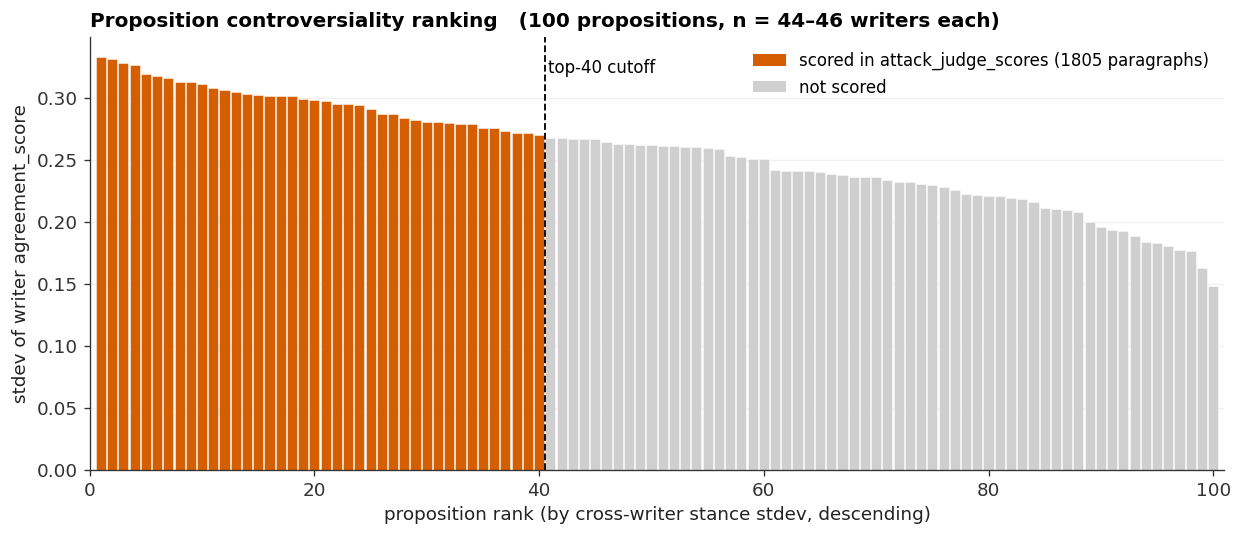

In [3]:
# Rank propositions by across-writer stance variance (controversiality).
_docs = pd.read_csv('../paul_data/prepared/documents.csv',
                    usecols=['document_id', 'proposition_id', 'paragraph_type',
                             'agreement_score'])
_props = pd.read_csv('../paul_data/main_phase_1/propositions.csv')

_writers_full = _docs[_docs['paragraph_type'] == 'writer']
controversy = (_writers_full.groupby('proposition_id')['agreement_score']
               .agg(stance_mean='mean', stance_std='std', n_writers='count')
               .reset_index()
               .merge(_props, on='proposition_id', how='left')
               .sort_values('stance_std', ascending=False)
               .reset_index(drop=True))
controversy['rank'] = controversy.index + 1

# Which propositions are actually in the scored corpus?
_scored_ids = pd.read_sql_query(
    "SELECT DISTINCT source_doc_id FROM attack_rewrites WHERE method='original'",
    conn)['source_doc_id']
_scored_props = set(_docs[_docs['document_id'].isin(_scored_ids)]['proposition_id'])
controversy['in_scored_corpus'] = controversy['proposition_id'].isin(_scored_props)

fig, ax = plt.subplots(figsize=(10.5, 4.6))
bar_color = np.where(controversy['in_scored_corpus'],
                     OKABE_ITO['vermilion'], '#CFCFCF')
ax.bar(controversy['rank'], controversy['stance_std'], 0.9,
       color=bar_color, edgecolor='white', linewidth=0.3)
ax.axvline(40.5, color=OKABE_ITO['black'], linestyle='--', linewidth=1.1)
ax.text(40.8, ax.get_ylim()[1] * 0.95, 'top-40 cutoff',
        ha='left', va='top', fontsize=10, color=OKABE_ITO['black'])

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=OKABE_ITO['vermilion'], label='scored in attack_judge_scores (1805 paragraphs)'),
    Patch(facecolor='#CFCFCF', label='not scored'),
], loc='upper right', frameon=False, fontsize=10)
ax.set_xlabel('proposition rank (by cross-writer stance stdev, descending)')
ax.set_ylabel('stdev of writer agreement_score')
ax.set_title('Proposition controversiality ranking   (100 propositions, n = 44–46 writers each)',
             loc='left')
ax.grid(axis='y', linestyle='-', alpha=0.5)
ax.grid(axis='x', visible=False)
ax.set_xlim(0, 101)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1a_controversy_ranking.png')
plt.show()

Human originals scored: 1805 paragraphs across 40 propositions


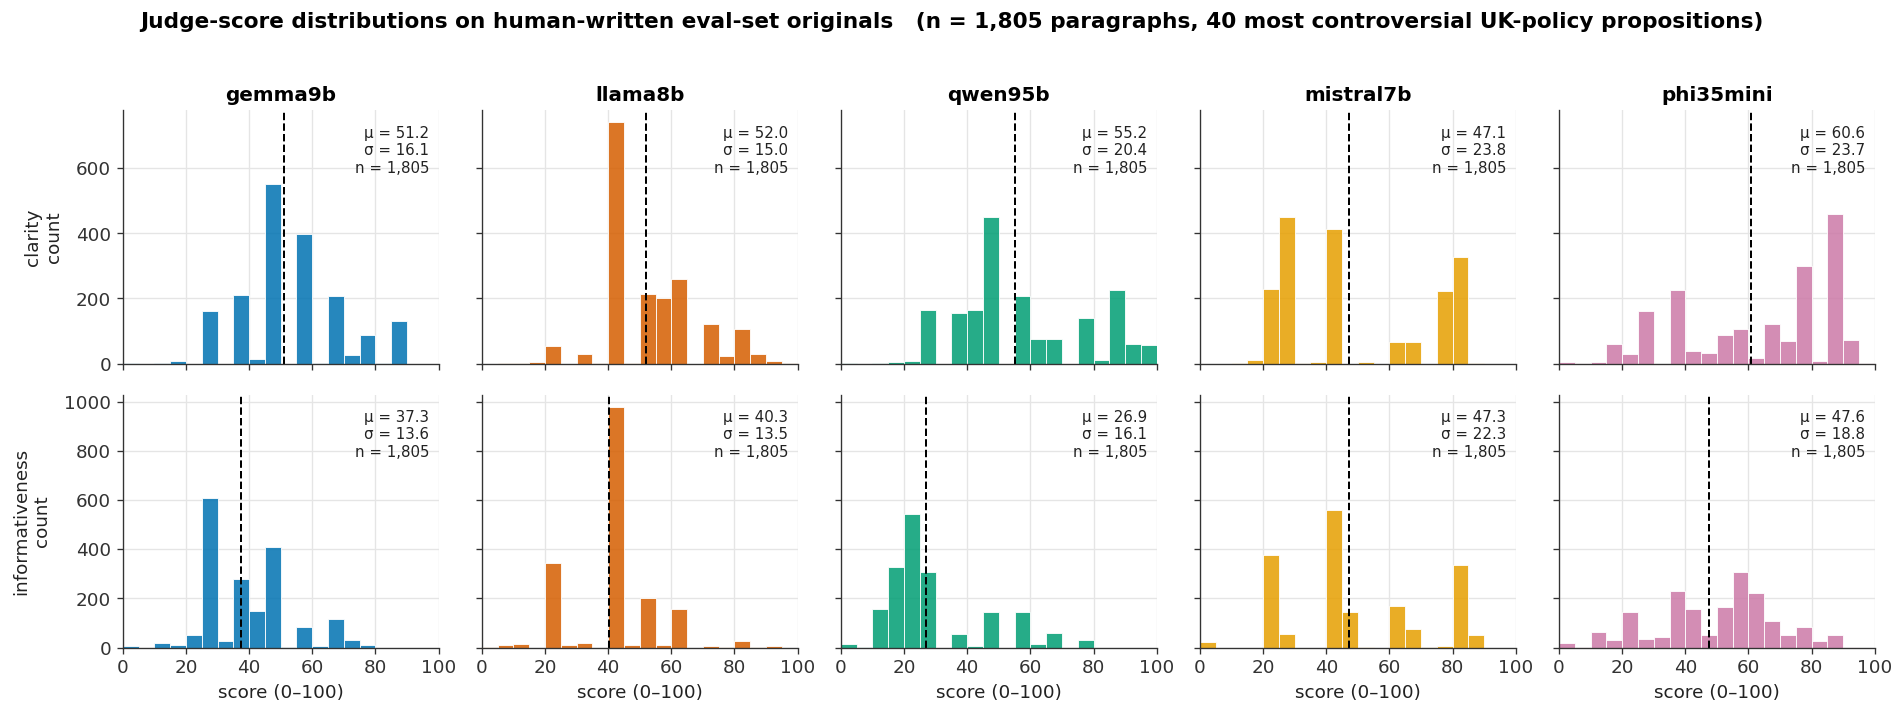

In [4]:
# Load originals for all 5 attack judges (full 1805-paragraph corpus).
ALL_5_JUDGES = ['judge_gemma9b', 'judge_llama8b', 'judge_qwen95b',
                'judge_mistral7b', 'judge_phi35mini']
JUDGE5_COLOR = {
    'judge_gemma9b':   OKABE_ITO['blue'],
    'judge_llama8b':   OKABE_ITO['vermilion'],
    'judge_qwen95b':   OKABE_ITO['green'],
    'judge_mistral7b': OKABE_ITO['orange'],
    'judge_phi35mini': OKABE_ITO['purple'],
}

orig_full = pd.read_sql_query(f'''
  SELECT ar.source_doc_id, ajs.judge_slug, ajs.criterion, ajs.score
  FROM attack_rewrites ar
  JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
  WHERE ar.method = 'original'
    AND ajs.judge_slug IN ({','.join(f"'{j}'" for j in ALL_5_JUDGES)})
''', conn)

_n_paragraphs = orig_full['source_doc_id'].nunique()
_n_props = (orig_full[['source_doc_id']]
            .merge(_docs[['document_id', 'proposition_id']],
                   left_on='source_doc_id', right_on='document_id')
            ['proposition_id'].nunique())
print(f'Human originals scored: {_n_paragraphs} paragraphs across {_n_props} propositions')

CRITERIA2 = ['clarity', 'informativeness']
BINS = np.arange(0, 105, 5)

fig, axes = plt.subplots(len(CRITERIA2), len(ALL_5_JUDGES),
                         figsize=(16, 5.8), sharex=True, sharey='row')

for i, criterion in enumerate(CRITERIA2):
    for j, judge in enumerate(ALL_5_JUDGES):
        ax = axes[i, j]
        vals = orig_full.query('criterion == @criterion and judge_slug == @judge')['score']
        ax.hist(vals, bins=BINS, color=JUDGE5_COLOR[judge], alpha=0.85,
                edgecolor='white', linewidth=0.6)
        ax.axvline(vals.mean(), color=OKABE_ITO['black'], linestyle='--', linewidth=1.2)
        ax.text(0.97, 0.94,
                f'μ = {vals.mean():.1f}\nσ = {vals.std(ddof=1):.1f}\nn = {len(vals):,}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                color='#222222')
        if i == 0:
            ax.set_title(judge.replace('judge_', ''))
        if i == len(CRITERIA2) - 1:
            ax.set_xlabel('score (0–100)')
        if j == 0:
            ax.set_ylabel(f'{criterion}\ncount', rotation=90, labelpad=8)
        ax.set_xlim(0, 100)

fig.suptitle(
    f'Judge-score distributions on human-written eval-set originals   '
    f'(n = {_n_paragraphs:,} paragraphs, 40 most controversial UK-policy propositions)',
    y=1.02, fontsize=13, fontweight='semibold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_distributions_originals.png')
plt.show()

## 3 — Clarity results: mean score by method × judge

`bon_panel` pooled across folds (see section 6 for the in-panel / held-out split).

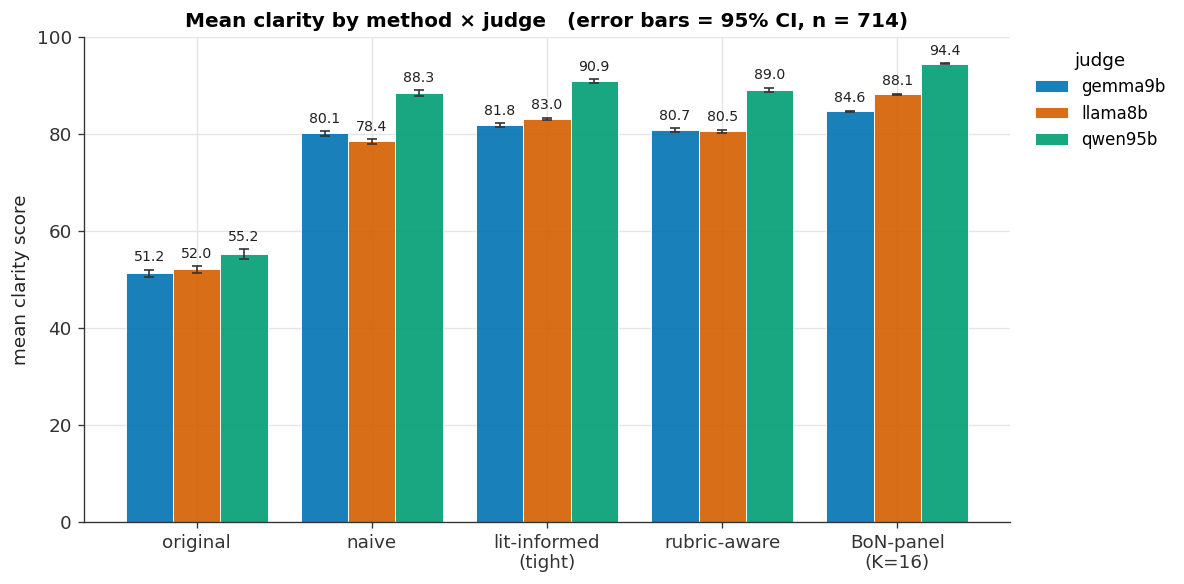

In [5]:
clarity = scores[scores['criterion'] == 'clarity']

agg = (clarity.groupby(['method', 'judge_slug'])['score']
       .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)))
       .reset_index())
agg['ci'] = 1.96 * agg['sem']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(METHODS))
width = 0.27
for i, judge in enumerate(JUDGES):
    sub = agg[agg['judge_slug'] == judge].set_index('method').reindex(METHODS)
    bars = ax.bar(x + (i - 1) * width, sub['mean'], width,
                  yerr=sub['ci'], capsize=3,
                  label=judge.replace('judge_', ''),
                  color=JUDGE_COLOR[judge], alpha=0.9,
                  edgecolor='white', linewidth=0.6,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    for bar, mean, ci in zip(bars, sub['mean'], sub['ci']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 1.2,
                f'{mean:.1f}', ha='center', va='bottom', fontsize=8.5,
                color='#222222')

ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABEL[m] for m in METHODS])
ax.set_ylabel('mean clarity score')
ax.set_ylim(0, 100)
ax.set_title('Mean clarity by method × judge   (error bars = 95% CI, n = 714)')
ax.legend(title='judge', loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_clarity_means.png')
plt.show()

## 4 — Paired clarity gain over `original`

Within-paragraph differences: `score(method) − score(original)` per (paragraph, judge). Paired CIs use the per-paragraph delta SE.

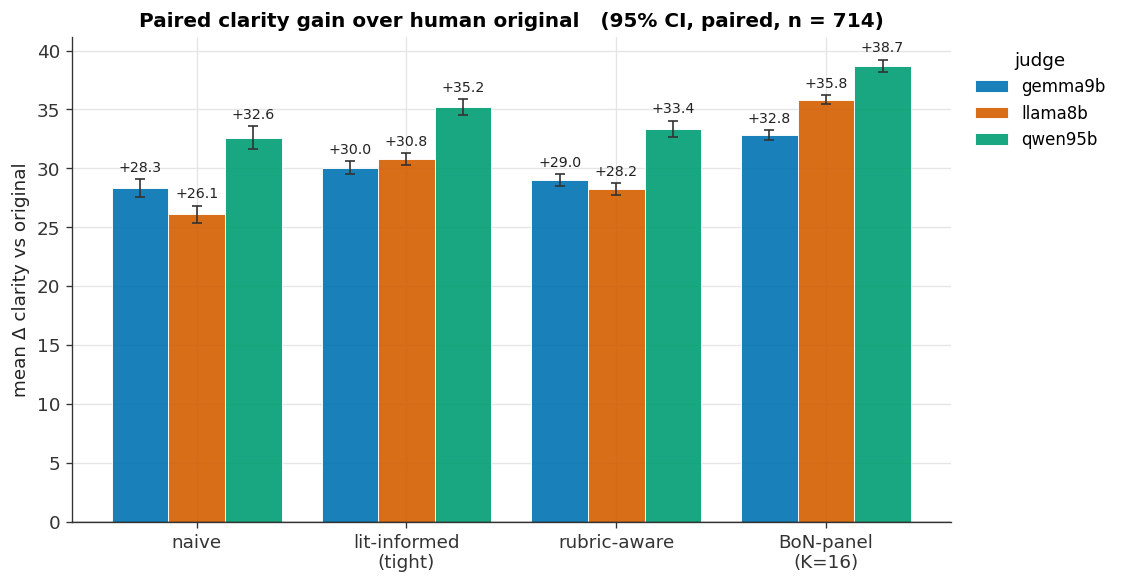

In [6]:
orig = (clarity[clarity['method'] == 'original']
        .groupby(['source_doc_id', 'judge_slug'])['score']
        .mean().rename('orig_score').reset_index())

pair = clarity[clarity['method'] != 'original'].merge(orig, on=['source_doc_id', 'judge_slug'])
pair['delta'] = pair['score'] - pair['orig_score']

delta_agg = (pair.groupby(['method', 'judge_slug'])['delta']
             .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)))
             .reset_index())
delta_agg['ci'] = 1.96 * delta_agg['sem']

methods_nb = [m for m in METHODS if m != 'original']
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(methods_nb))
width = 0.27
for i, judge in enumerate(JUDGES):
    sub = delta_agg[delta_agg['judge_slug'] == judge].set_index('method').reindex(methods_nb)
    bars = ax.bar(x + (i - 1) * width, sub['mean'], width,
                  yerr=sub['ci'], capsize=3,
                  label=judge.replace('judge_', ''),
                  color=JUDGE_COLOR[judge], alpha=0.9,
                  edgecolor='white', linewidth=0.6,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    for bar, mean, ci in zip(bars, sub['mean'], sub['ci']):
        if mean >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 0.4,
                    f'{mean:+.1f}', ha='center', va='bottom', fontsize=8.5, color='#222222')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - ci - 0.4,
                    f'{mean:+.1f}', ha='center', va='top', fontsize=8.5, color='#222222')

ax.axhline(0, color=OKABE_ITO['black'], linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABEL[m] for m in methods_nb])
ax.set_ylabel('mean Δ clarity vs original')
ax.set_title('Paired clarity gain over human original   (95% CI, paired, n = 714)')
ax.legend(title='judge', loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_clarity_deltas.png')
plt.show()

## 5 — Clarity score distribution by method, faceted by judge

Boxes: IQR. Whiskers: 1.5×IQR. Diamonds: mean.

/tmp/ipykernel_2162335/2450747871.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2162335/2450747871.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2162335/2450747871.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


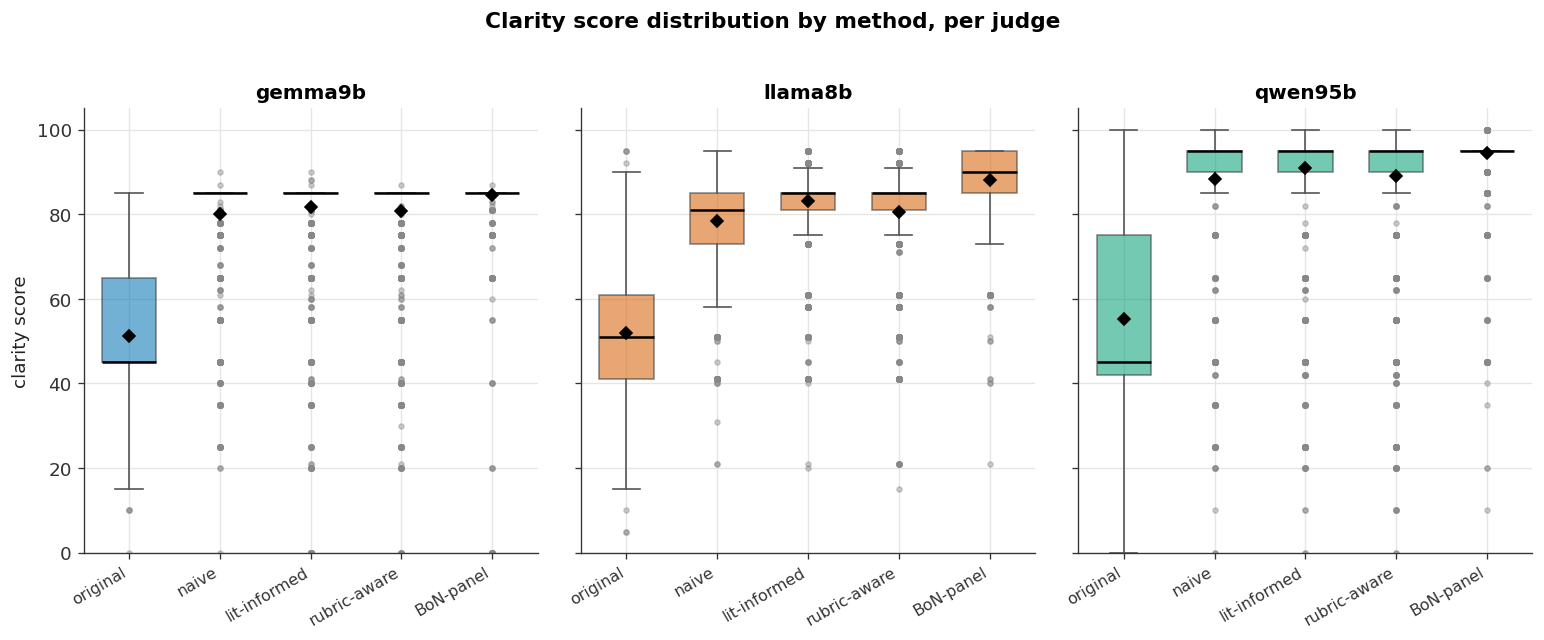

In [7]:
SHORT_LABELS = {
    'original': 'original',
    'naive': 'naive',
    'lit_informed_tight': 'lit-informed',
    'rubric_aware': 'rubric-aware',
    'bon_panel': 'BoN-panel',
}

fig, axes = plt.subplots(1, len(JUDGES), figsize=(13, 5.2), sharey=True)
for ax, judge in zip(axes, JUDGES):
    data = [clarity.query('method == @m and judge_slug == @judge')['score'].values for m in METHODS]
    bp = ax.boxplot(
        data, labels=[SHORT_LABELS[m] for m in METHODS],
        showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': OKABE_ITO['black'],
                    'markeredgecolor': OKABE_ITO['black'], 'markersize': 5},
        medianprops={'color': OKABE_ITO['black'], 'linewidth': 1.5},
        whiskerprops={'color': '#555555'},
        capprops={'color': '#555555'},
        flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': '#888888',
                     'markeredgecolor': '#888888', 'alpha': 0.4},
        patch_artist=True, widths=0.6,
    )
    for patch in bp['boxes']:
        patch.set_facecolor(JUDGE_COLOR[judge])
        patch.set_alpha(0.55)
        patch.set_edgecolor('#333333')
    ax.set_title(judge.replace('judge_', ''))
    ax.set_ylim(0, 105)
    if ax is axes[0]:
        ax.set_ylabel('clarity score')
    ax.tick_params(axis='x', labelsize=9.5)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

fig.suptitle('Clarity score distribution by method, per judge',
             y=1.02, fontsize=13, fontweight='semibold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_clarity_distributions.png')
plt.show()

## 6 — `bon_panel` cross-judge transfer

Per judge, the mean `bon_panel` score partitioned by the judge's role in the fold. 'in-panel' pools the two folds where this judge was a selector; 'held-out' uses the one fold where it was not. Dashed line = `original` mean for the same judge.

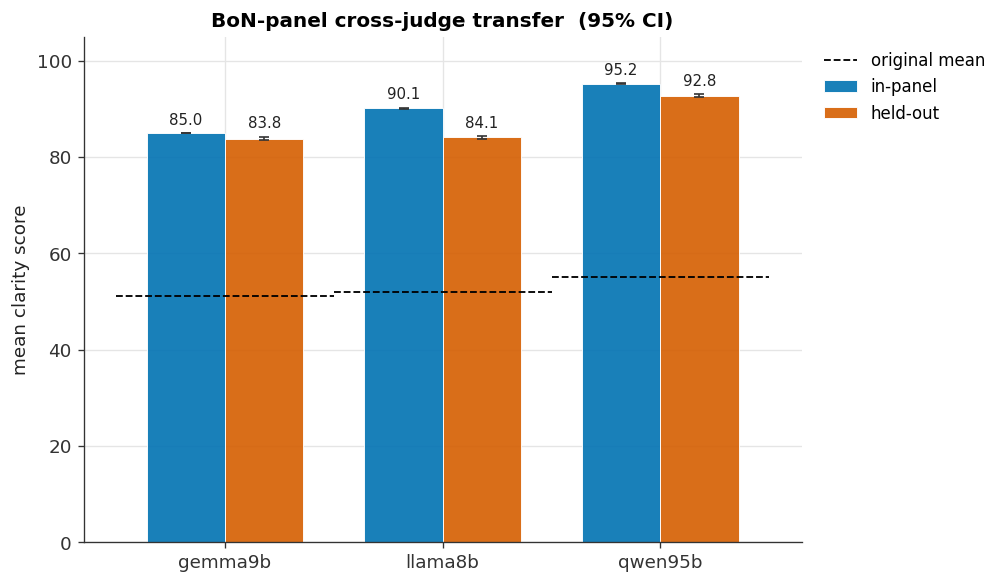

In [8]:
bp_df = clarity[clarity['method'] == 'bon_panel'].copy()
bp_df['role'] = np.where(
    bp_df['judge_slug'] == bp_df['fold'].map(HELD_OUT_BY_FOLD),
    'held-out', 'in-panel',
)

transfer = (bp_df.groupby(['judge_slug', 'role'])['score']
            .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)))
            .reset_index())
transfer['ci'] = 1.96 * transfer['sem']

orig_means = (clarity[clarity['method'] == 'original']
              .groupby('judge_slug')['score'].mean())

ROLE_COLOR = {'in-panel': OKABE_ITO['blue'], 'held-out': OKABE_ITO['vermilion']}

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(JUDGES))
width = 0.36
for i, role in enumerate(['in-panel', 'held-out']):
    sub = transfer[transfer['role'] == role].set_index('judge_slug').reindex(JUDGES)
    bars = ax.bar(x + (i - 0.5) * width, sub['mean'], width,
                  yerr=sub['ci'], capsize=3,
                  label=role, color=ROLE_COLOR[role], alpha=0.9,
                  edgecolor='white', linewidth=0.6,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    for bar, mean, ci in zip(bars, sub['mean'], sub['ci']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 1.2,
                f'{mean:.1f}', ha='center', va='bottom', fontsize=9, color='#222222')

for i, judge in enumerate(JUDGES):
    ax.hlines(orig_means[judge], x[i] - 0.5, x[i] + 0.5,
              linestyle='--', color=OKABE_ITO['black'], linewidth=1.1)

ax.plot([], [], linestyle='--', color=OKABE_ITO['black'], linewidth=1.1,
        label='original mean')
ax.set_xticks(x)
ax.set_xticklabels([j.replace('judge_', '') for j in JUDGES])
ax.set_ylabel('mean clarity score')
ax.set_ylim(0, 105)
ax.set_title('BoN-panel cross-judge transfer  (95% CI)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_bon_panel_transfer.png')
plt.show()

## 7 — Attack-method improvement analysis

Three questions across the full 5-judge panel (`gemma9b`, `llama8b`, `qwen95b`, `mistral7b`, `phi35mini`) and both criteria:

1. **Feedback-free methods** (`naive`, `lit_informed_tight`, `rubric_aware`): paired improvement vs `original`, pooled over judges, split by method × criterion.
2. **Feedback-using methods** (`icir`, `bon_panel`, `grpo_400step`): paired improvement vs `original`, pooled over folds, split by method × criterion × in-sample/out-of-sample judge role.
3. **Agreement-score shift and stance flip**: rewrite-vs-original agreement_score drift; % of paragraphs whose stance flips across the 0.4 / 0.6 bands (paragraphs with original in (0.4, 0.6) excluded).

**Judge roles per fold** (in-panel = used as selector/feedback source; out-of-sample = all other judges including held-out attack judge and the two never-seen judges `mistral7b`, `phi35mini`):

| fold | in-panel | held-out attack | always out-of-sample |
|---|---|---|---|
| 1 | qwen95b, llama8b | gemma9b | mistral7b, phi35mini |
| 2 | qwen95b, gemma9b | llama8b | mistral7b, phi35mini |
| 3 | llama8b, gemma9b | qwen95b | mistral7b, phi35mini |

In [9]:
FEEDBACK_FREE = ['naive', 'lit_informed_tight', 'rubric_aware']
FEEDBACK_USING = ['icir', 'bon_panel', 'grpo_400step']
ALL_METHODS = FEEDBACK_FREE + FEEDBACK_USING
ALL_JUDGES = ['judge_gemma9b', 'judge_llama8b', 'judge_qwen95b', 'judge_mistral7b', 'judge_phi35mini']
IN_PANEL_BY_FOLD = {
    1: {'judge_qwen95b', 'judge_llama8b'},
    2: {'judge_qwen95b', 'judge_gemma9b'},
    3: {'judge_llama8b', 'judge_gemma9b'},
}

method_list = ','.join(f"'{m}'" for m in ALL_METHODS)
judge_list = ','.join(f"'{j}'" for j in ALL_JUDGES)

orig_scores_all = pd.read_sql_query(f'''
  SELECT ar.source_doc_id, ajs.judge_slug, ajs.criterion, ajs.score AS orig_score
  FROM attack_rewrites ar
  JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
  WHERE ar.method = 'original'
    AND ar.source_doc_id IN (SELECT DISTINCT source_doc_id FROM attack_rewrites WHERE method != 'original')
    AND ajs.judge_slug IN ({judge_list})
''', conn)

rewrite_scores = pd.read_sql_query(f'''
  SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
         ar.criterion AS rewrite_criterion,
         ajs.judge_slug, ajs.score
  FROM attack_rewrites ar
  JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
  WHERE ar.method IN ({method_list})
    AND ajs.judge_slug IN ({judge_list})
    AND ajs.criterion = ar.criterion
''', conn)

deltas = rewrite_scores.merge(
    orig_scores_all.rename(columns={'criterion': 'rewrite_criterion'}),
    on=['source_doc_id', 'judge_slug', 'rewrite_criterion'], how='left',
)
assert deltas['orig_score'].notna().all()
deltas['delta'] = deltas['score'] - deltas['orig_score']
print(f'rows: {len(deltas):,}  methods: {sorted(deltas.method.unique())}  criteria: {sorted(deltas.rewrite_criterion.unique())}')

rows: 203,490  methods: ['bon_panel', 'grpo_400step', 'icir', 'lit_informed_tight', 'naive', 'rubric_aware']  criteria: ['clarity', 'informativeness']


In [10]:
# --- Plotting helpers for section 7 ---
METHOD_ORDER = ['naive', 'rubric_aware', 'lit_informed_tight', 'icir', 'bon_panel', 'grpo_400step']
METHOD_TICK = {
    'naive': 'naive',
    'rubric_aware': 'rubric-aware',
    'lit_informed_tight': 'lit-informed\n(tight)',
    'icir': 'ICIR',
    'bon_panel': 'BoN-panel',
    'grpo_400step': 'GRPO\n(400 step)',
}
CRITERION_COLOR = {
    'clarity': OKABE_ITO['blue'],
    'informativeness': OKABE_ITO['vermilion'],
}
ROLE_COLOR = {
    'in_sample': OKABE_ITO['blue'],
    'out_of_sample': OKABE_ITO['vermilion'],
    'oos_heldout_attack': OKABE_ITO['orange'],
    'oos_never_seen': OKABE_ITO['green'],
}
ROLE_LABEL = {
    'in_sample': 'in-sample (selectors)',
    'out_of_sample': 'out-of-sample',
    'oos_heldout_attack': 'held-out attack judge',
    'oos_never_seen': 'never-seen (mistral / phi)',
}


def _style_bar_axes(ax, xlabel=None, ylabel=None, title=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    ax.grid(axis='x', visible=False)
    ax.axhline(0, color=OKABE_ITO['black'], linewidth=0.8)


def _annotate_bars(ax, bars, values, cis=None, fmt='{:+.1f}', fontsize=8.5, pad=0.4):
    for i, bar in enumerate(bars):
        h = bar.get_height()
        ci = cis[i] if cis is not None else 0
        if h >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + ci + pad,
                    fmt.format(values[i]), ha='center', va='bottom',
                    fontsize=fontsize, color='#222222')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, h - ci - pad,
                    fmt.format(values[i]), ha='center', va='top',
                    fontsize=fontsize, color='#222222')


### 7.1 — Feedback-free methods: paired improvement vs original

Pooled across all 5 judges and 714 paragraphs. `naive` has clarity-targeted rewrites only, so no informativeness row. 95% CIs treat each (paragraph, judge) delta as an independent observation — clustered SEs would be wider but the ranking is unaffected.

In [11]:
ff = deltas[deltas['method'].isin(FEEDBACK_FREE)]
q1 = (ff.groupby(['method', 'rewrite_criterion'])['delta']
        .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n='count')
        .reset_index()
        .rename(columns={'rewrite_criterion': 'criterion'}))
q1['ci95'] = 1.96 * q1['sem']
q1 = q1[['method', 'criterion', 'mean', 'ci95', 'n']]
q1 = q1.sort_values(['criterion', 'mean'], ascending=[True, False]).reset_index(drop=True)
q1.round(2)

,method,criterion,mean,ci95,n
0,lit_informed_tight,clarity,30.86,0.40,10710
1,rubric_aware,clarity,29.13,0.40,10710
2,naive,clarity,28.46,0.40,10710
3,lit_informed_tight,informativeness,21.33,0.43,10710
4,rubric_aware,informativeness,14.01,0.38,10710


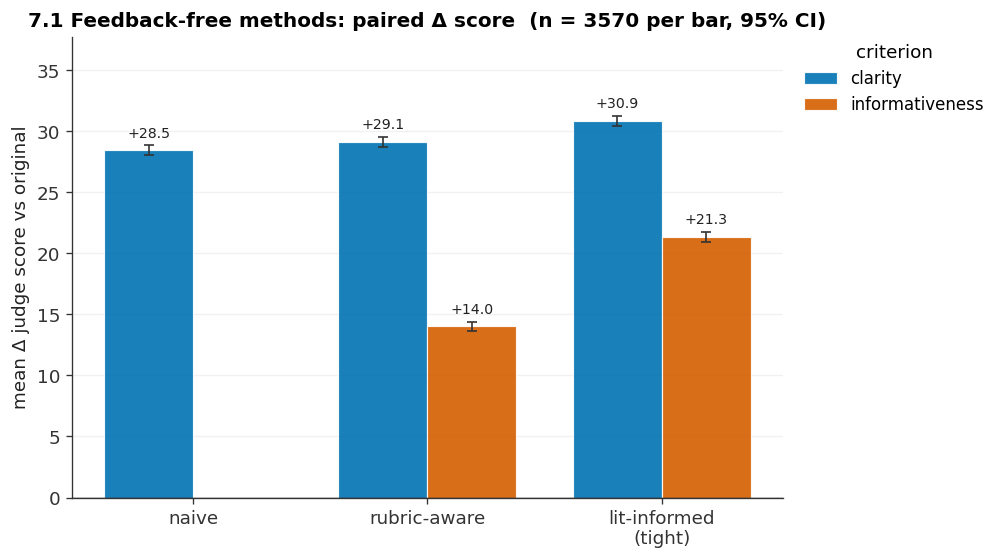

In [12]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
criteria = ['clarity', 'informativeness']

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(methods_ff))
width = 0.38
for i, crit in enumerate(criteria):
    sub = q1[q1['criterion'] == crit].set_index('method').reindex(methods_ff)
    means = sub['mean'].values
    cis = sub['ci95'].values
    bars = ax.bar(x + (i - 0.5) * width, means, width,
                  yerr=cis, capsize=3,
                  label=crit, color=CRITERION_COLOR[crit], alpha=0.9,
                  edgecolor='white', linewidth=0.7,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    valid = ~np.isnan(means)
    _annotate_bars(ax, [b for b, v in zip(bars, valid) if v],
                   means[valid], cis[valid], fmt='{:+.1f}')

ax.set_xticks(x)
ax.set_xticklabels([METHOD_TICK[m] for m in methods_ff])
_style_bar_axes(ax,
                ylabel='mean Δ judge score vs original',
                title='7.1 Feedback-free methods: paired Δ score  (n = 3570 per bar, 95% CI)')
ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
ax.legend(title='criterion', loc='upper left',
          bbox_to_anchor=(1.02, 1.0), frameon=False, borderaxespad=0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_1_feedback_free_delta.png')
plt.show()

### 7.2 — Feedback-using methods: paired improvement split by judge role

Each (paragraph, fold, judge) observation is tagged `in_sample` if the judge was in that fold's in-panel selector set, else `out_of_sample`. Pooled over folds.

For finer-grained inspection, a secondary split further separates out-of-sample into the held-out attack judge vs. the two never-seen judges (`mistral7b`, `phi35mini`).

In [13]:
fu = deltas[deltas['method'].isin(FEEDBACK_USING)].copy()
fu['in_panel'] = fu.apply(
    lambda r: r['judge_slug'] in IN_PANEL_BY_FOLD[int(r['fold'])], axis=1)
fu['role'] = np.where(fu['in_panel'], 'in_sample', 'out_of_sample')

q2 = (fu.groupby(['method', 'rewrite_criterion', 'role'])['delta']
        .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n='count')
        .reset_index()
        .rename(columns={'rewrite_criterion': 'criterion'}))
q2['ci95'] = 1.96 * q2['sem']
q2 = q2[['method', 'criterion', 'role', 'mean', 'ci95', 'n']]
q2 = q2.sort_values(['criterion', 'method', 'role']).reset_index(drop=True)
q2.round(2)

,method,criterion,role,mean,ci95,n
0,bon_panel,clarity,in_sample,36.24,0.31,12852
1,bon_panel,clarity,out_of_sample,31.80,0.31,19278
2,grpo_400step,clarity,in_sample,35.31,0.31,12852
3,grpo_400step,clarity,out_of_sample,32.41,0.31,19278
4,icir,clarity,in_sample,26.89,0.59,4284
5,icir,clarity,out_of_sample,26.65,0.55,6426
6,bon_panel,informativeness,in_sample,34.78,0.32,12852
7,bon_panel,informativeness,out_of_sample,30.98,0.31,19278
8,grpo_400step,informativeness,in_sample,34.19,0.39,12852
9,grpo_400step,informativeness,out_of_sample,31.21,0.31,19278


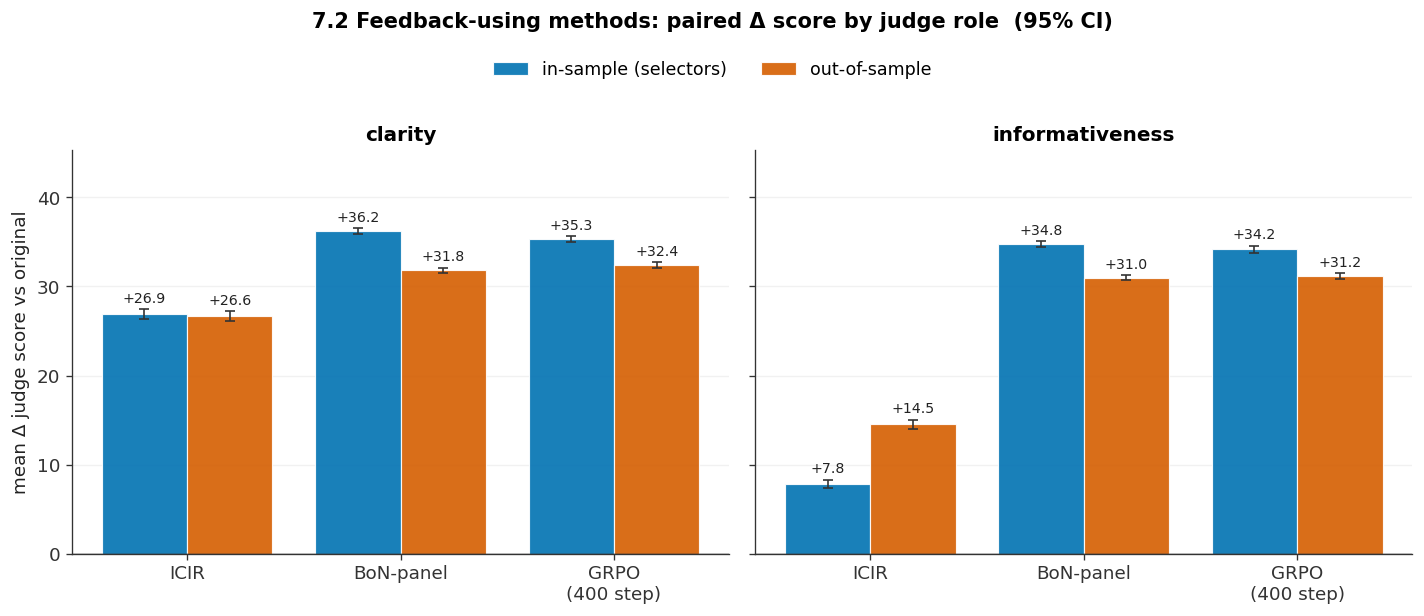

In [14]:
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']
roles = ['in_sample', 'out_of_sample']

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), sharey=True)
role_handles = []
for ax, crit in zip(axes, criteria):
    x = np.arange(len(methods_fu))
    width = 0.4
    for i, role in enumerate(roles):
        sub = (q2[(q2['criterion'] == crit) & (q2['role'] == role)]
               .set_index('method').reindex(methods_fu))
        means = sub['mean'].values
        cis = sub['ci95'].values
        bars = ax.bar(x + (i - 0.5) * width, means, width,
                      yerr=cis, capsize=3,
                      label=ROLE_LABEL[role], color=ROLE_COLOR[role], alpha=0.9,
                      edgecolor='white', linewidth=0.7,
                      error_kw={'ecolor': '#333333', 'elinewidth': 1})
        _annotate_bars(ax, bars, means, cis, fmt='{:+.1f}')
        if ax is axes[0]:
            role_handles.append(bars)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
    _style_bar_axes(ax,
                    ylabel='mean Δ judge score vs original' if ax is axes[0] else None,
                    title=crit)

# shared y-axis with headroom for legend above bars
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.18)

fig.legend([h for h in role_handles], [ROLE_LABEL[r] for r in roles],
           loc='upper center', bbox_to_anchor=(0.5, 0.965),
           ncol=2, frameon=False, fontsize=10.5)
fig.suptitle('7.2 Feedback-using methods: paired Δ score by judge role  (95% CI)',
             y=1.02, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'fig7_2_feedback_using_delta.png')
plt.show()

In [15]:
ATTACK_PANEL = {'judge_gemma9b', 'judge_llama8b', 'judge_qwen95b'}

def role_fine(r):
    if r['judge_slug'] in IN_PANEL_BY_FOLD[int(r['fold'])]:
        return 'in_sample'
    if r['judge_slug'] in ATTACK_PANEL:
        return 'oos_heldout_attack'
    return 'oos_never_seen'

fu['role_fine'] = fu.apply(role_fine, axis=1)
q2b = (fu.groupby(['method', 'rewrite_criterion', 'role_fine'])['delta']
         .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n='count')
         .reset_index()
         .rename(columns={'rewrite_criterion': 'criterion'}))
q2b['ci95'] = 1.96 * q2b['sem']
ROLE_ORDER = {'in_sample': 0, 'oos_heldout_attack': 1, 'oos_never_seen': 2}
q2b['_role_ord'] = q2b['role_fine'].map(ROLE_ORDER)
q2b = (q2b.sort_values(['criterion', 'method', '_role_ord'])
          .drop(columns='_role_ord')
          .reset_index(drop=True))
q2b = q2b[['method', 'criterion', 'role_fine', 'mean', 'ci95', 'n']]
q2b.round(2)

,method,criterion,role_fine,mean,ci95,n
0,bon_panel,clarity,in_sample,36.24,0.31,12852
1,bon_panel,clarity,oos_heldout_attack,33.62,0.46,6426
2,bon_panel,clarity,oos_never_seen,30.89,0.41,12852
3,grpo_400step,clarity,in_sample,35.31,0.31,12852
4,grpo_400step,clarity,oos_heldout_attack,34.95,0.44,6426
5,grpo_400step,clarity,oos_never_seen,31.14,0.41,12852
6,icir,clarity,in_sample,26.89,0.59,4284
7,icir,clarity,oos_heldout_attack,27.01,0.83,2142
8,icir,clarity,oos_never_seen,26.47,0.71,4284
9,bon_panel,informativeness,in_sample,34.78,0.32,12852


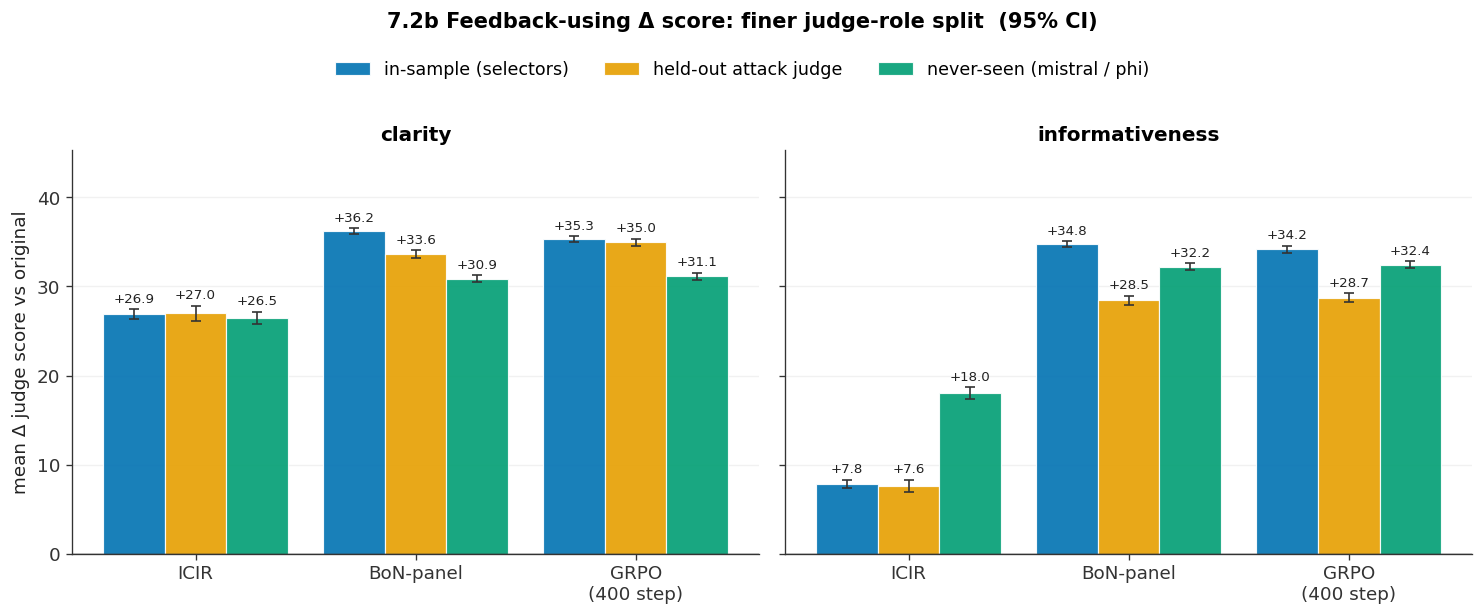

In [16]:
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']
roles_fine = ['in_sample', 'oos_heldout_attack', 'oos_never_seen']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)
handles_by_role = {}
for ax, crit in zip(axes, criteria):
    x = np.arange(len(methods_fu))
    width = 0.28
    for i, role in enumerate(roles_fine):
        sub = (q2b[(q2b['criterion'] == crit) & (q2b['role_fine'] == role)]
               .set_index('method').reindex(methods_fu))
        means = sub['mean'].values
        cis = sub['ci95'].values
        bars = ax.bar(x + (i - 1) * width, means, width,
                      yerr=cis, capsize=3,
                      label=ROLE_LABEL[role], color=ROLE_COLOR[role], alpha=0.9,
                      edgecolor='white', linewidth=0.7,
                      error_kw={'ecolor': '#333333', 'elinewidth': 1})
        _annotate_bars(ax, bars, means, cis, fmt='{:+.1f}', fontsize=8)
        if ax is axes[0]:
            handles_by_role[role] = bars
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
    _style_bar_axes(ax,
                    ylabel='mean Δ judge score vs original' if ax is axes[0] else None,
                    title=crit)

axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.18)

fig.legend([handles_by_role[r] for r in roles_fine],
           [ROLE_LABEL[r] for r in roles_fine],
           loc='upper center', bbox_to_anchor=(0.5, 0.965),
           ncol=3, frameon=False, fontsize=10.5)
fig.suptitle('7.2b Feedback-using Δ score: finer judge-role split  (95% CI)',
             y=1.02, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'fig7_2b_feedback_using_delta_fine.png')
plt.show()

### 7.3 — Agreement-score shift and stance flip

`agreement_score` is the DeBERTa-v3-base regressor output on [0, 1], where 0 = disagrees with the proposition and 1 = agrees. Shift = `agreement(rewrite) − agreement(original)` for the same source paragraph.

**Flip criterion** (tightened): paragraph is *flipped* if the original score is ≤ 0.25 and the rewrite is ≥ 0.75, or vice versa (strong stance → strong opposite stance). Paragraphs whose original lies strictly between 0.25 and 0.75 are excluded because their original stance is too moderate to flip meaningfully. Of the 714 eval paragraphs: 246 have an original ≤ 0.25 (clear anti), 268 have ≥ 0.75 (clear pro), and 200 fall in the excluded middle.

In [17]:
orig_agree = pd.read_sql_query('''
  SELECT ar.source_doc_id, aas.score AS orig_agree
  FROM attack_rewrites ar
  JOIN attack_agreement_scores aas ON aas.rewrite_id = ar.rewrite_id
  WHERE ar.method = 'original'
    AND ar.source_doc_id IN (SELECT DISTINCT source_doc_id FROM attack_rewrites WHERE method != 'original')
''', conn)

rew_agree = pd.read_sql_query(f'''
  SELECT ar.source_doc_id, ar.method, ar.fold,
         ar.criterion AS rewrite_criterion,
         aas.score AS rewrite_agree
  FROM attack_rewrites ar
  JOIN attack_agreement_scores aas ON aas.rewrite_id = ar.rewrite_id
  WHERE ar.method IN ({method_list})
''', conn)

# Attach proposition_leaning from paul_data (left / right / neither).
_docs = pd.read_csv('../paul_data/prepared/documents.csv',
                    usecols=['document_id', 'proposition_id'])
_props = pd.read_csv('../paul_data/main_phase_1/propositions.csv',
                     usecols=['proposition_id', 'proposition_leaning'])
_leaning = (_docs.merge(_props, on='proposition_id', how='left')
                 [['document_id', 'proposition_leaning']]
                 .rename(columns={'document_id': 'source_doc_id'}))

agree = (rew_agree.merge(orig_agree, on='source_doc_id', how='left')
                  .merge(_leaning, on='source_doc_id', how='left'))
assert agree['orig_agree'].notna().all()
assert agree['proposition_leaning'].notna().all()
agree['shift'] = agree['rewrite_agree'] - agree['orig_agree']
agree['abs_shift'] = agree['shift'].abs()

FLIP_LOW, FLIP_HIGH = 0.25, 0.75

def classify(orig, new):
    if FLIP_LOW < orig < FLIP_HIGH:
        return 'excluded'
    if orig <= FLIP_LOW and new >= FLIP_HIGH:
        return 'flip_low_to_high'
    if orig >= FLIP_HIGH and new <= FLIP_LOW:
        return 'flip_high_to_low'
    return 'not_flipped'

agree['flip_class'] = [classify(o, n) for o, n in zip(agree['orig_agree'], agree['rewrite_agree'])]
print(f'rows: {len(agree):,}  leaning counts: '
      + ', '.join(f'{k}={v}' for k, v in agree.groupby("proposition_leaning").size().items()))

rows: 40,698  leaning counts: left=25251, neither=969, right=14478


#### 7.3a — Average shift in `agreement_score`

Two complementary views:

1. **7.3a.i (absolute):** mean of |shift| — magnitude of drift away from the writer's original stance, regardless of direction. Captures "how far do the rewrites move semantically".
2. **7.3a.ii (signed, by wing):** mean of signed shift with three series per method — pooled / left-wing propositions / right-wing propositions. Signed shift lets cancellations happen (a rewrite that pushes anti-stance paragraphs toward pro and pro-stance paragraphs toward anti will net out near zero), so the split by proposition leaning reveals whether the rewriters have a consistent directional bias.

Proposition leanings come from `paul_data/main_phase_1/propositions.csv` (`proposition_leaning` ∈ {left, right, neither}). Of the 714 eval paragraphs: 443 on left-wing propositions, 254 on right-wing, 17 on "neither". The wing-split panel below excludes "neither"; the pooled series includes all 714.

In [18]:
# -- (i) absolute shift --
def _agg(series):
    return pd.Series({'mean': series.mean(),
                      'ci95': 1.96 * series.std(ddof=1) / np.sqrt(len(series)),
                      'n': len(series)})

abs_ff = (agree[agree['method'].isin(FEEDBACK_FREE)]
          .groupby('method')['abs_shift'].apply(_agg).unstack()
          .reset_index()
          .sort_values('mean', ascending=False).reset_index(drop=True))
abs_fu = (agree[agree['method'].isin(FEEDBACK_USING)]
          .groupby(['method', 'rewrite_criterion'])['abs_shift'].apply(_agg).unstack()
          .reset_index()
          .rename(columns={'rewrite_criterion': 'criterion'})
          .sort_values(['criterion', 'mean'], ascending=[True, False]).reset_index(drop=True))

print('7.3a.i — Average |shift| in agreement_score (95% CI)')
print()
print('Feedback-free (pooled over criteria):')
print(abs_ff.round(3).to_string(index=False))
print()
print('Feedback-using (pooled over folds):')
print(abs_fu.round(3).to_string(index=False))

# -- (ii) signed shift, split by leaning --
def _shift_by_leaning(df, group_cols):
    rows = []
    for leaning in ['pooled', 'left', 'right']:
        sub = df if leaning == 'pooled' else df[df['proposition_leaning'] == leaning]
        agg = sub.groupby(group_cols)['shift'].apply(_agg).unstack().reset_index()
        agg['leaning'] = leaning
        rows.append(agg)
    return pd.concat(rows, ignore_index=True)

signed_ff = _shift_by_leaning(agree[agree['method'].isin(FEEDBACK_FREE)], ['method'])
signed_fu = _shift_by_leaning(agree[agree['method'].isin(FEEDBACK_USING)],
                              ['method', 'rewrite_criterion']).rename(
                              columns={'rewrite_criterion': 'criterion'})

print()
print('7.3a.ii — Average signed shift in agreement_score, by proposition leaning (95% CI)')
print()
print('Feedback-free:')
print(signed_ff[['method', 'leaning', 'mean', 'ci95', 'n']].round(3).to_string(index=False))
print()
print('Feedback-using:')
print(signed_fu[['method', 'criterion', 'leaning', 'mean', 'ci95', 'n']].round(3).to_string(index=False))

7.3a.i — Average |shift| in agreement_score (95% CI)

Feedback-free (pooled over criteria):
            method  mean  ci95      n
lit_informed_tight 0.245 0.008 4284.0
      rubric_aware 0.209 0.007 4284.0
             naive 0.164 0.009 2142.0

Feedback-using (pooled over folds):
      method       criterion  mean  ci95      n
   bon_panel         clarity 0.258 0.006 6426.0
grpo_400step         clarity 0.232 0.006 6426.0
        icir         clarity 0.183 0.010 2142.0
   bon_panel informativeness 0.246 0.006 6426.0
grpo_400step informativeness 0.227 0.006 6426.0
        icir informativeness 0.208 0.010 2142.0

7.3a.ii — Average signed shift in agreement_score, by proposition leaning (95% CI)

Feedback-free:
            method leaning  mean  ci95      n
lit_informed_tight  pooled 0.225 0.008 4284.0
             naive  pooled 0.136 0.009 2142.0
      rubric_aware  pooled 0.188 0.008 4284.0
lit_informed_tight    left 0.241 0.010 2658.0
             naive    left 0.151 0.012 1329.0
      r

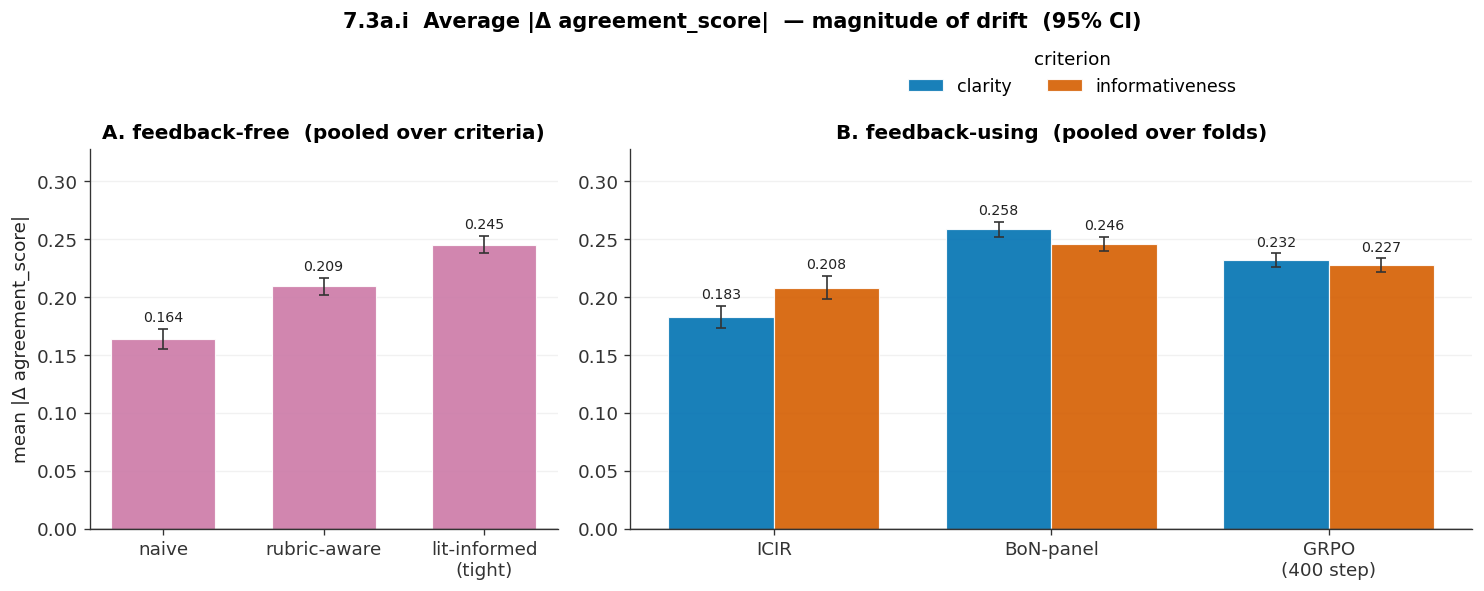

In [19]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8),
                         gridspec_kw={'width_ratios': [1, 1.8]})

# Panel A: feedback-free
axA = axes[0]
sub = abs_ff.set_index('method').reindex(methods_ff)
means = sub['mean'].values
cis = sub['ci95'].values
x = np.arange(len(methods_ff))
bars = axA.bar(x, means, 0.65, yerr=cis, capsize=3,
               color=OKABE_ITO['purple'], alpha=0.9,
               edgecolor='white', linewidth=0.7,
               error_kw={'ecolor': '#333333', 'elinewidth': 1})
_annotate_bars(axA, bars, means, cis, fmt='{:.3f}', pad=0.004)
axA.set_xticks(x)
axA.set_xticklabels([METHOD_TICK[m] for m in methods_ff])
_style_bar_axes(axA,
                ylabel='mean |Δ agreement_score|',
                title='A. feedback-free  (pooled over criteria)')

# Panel B: feedback-using
axB = axes[1]
x = np.arange(len(methods_fu))
width = 0.38
crit_handles = []
for i, crit in enumerate(criteria):
    sub = (abs_fu[abs_fu['criterion'] == crit]
           .set_index('method').reindex(methods_fu))
    means = sub['mean'].values
    cis = sub['ci95'].values
    bars = axB.bar(x + (i - 0.5) * width, means, width,
                   yerr=cis, capsize=3,
                   label=crit, color=CRITERION_COLOR[crit], alpha=0.9,
                   edgecolor='white', linewidth=0.7,
                   error_kw={'ecolor': '#333333', 'elinewidth': 1})
    _annotate_bars(axB, bars, means, cis, fmt='{:.3f}', pad=0.004)
    crit_handles.append(bars)
axB.set_xticks(x)
axB.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
_style_bar_axes(axB, title='B. feedback-using  (pooled over folds)')

ymax = max(axA.get_ylim()[1], axB.get_ylim()[1]) * 1.18
for ax in axes:
    ax.set_ylim(0, ymax)

fig.legend(crit_handles, criteria, title='criterion',
           loc='upper center', bbox_to_anchor=(0.72, 0.98),
           ncol=2, frameon=False, fontsize=10.5)
fig.suptitle('7.3a.i  Average |Δ agreement_score|  — magnitude of drift  (95% CI)',
             y=1.02, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'fig7_3a_abs_shift.png')
plt.show()

##### Signed shift, by proposition leaning

Same methods, but each method now has three bars: pooled (all 714 paragraphs), left-wing propositions only (443), right-wing propositions only (254). "Neither" propositions (17) are excluded from the wing bars but included in pooled. A symmetric y-axis makes positive vs negative drifts visually comparable.

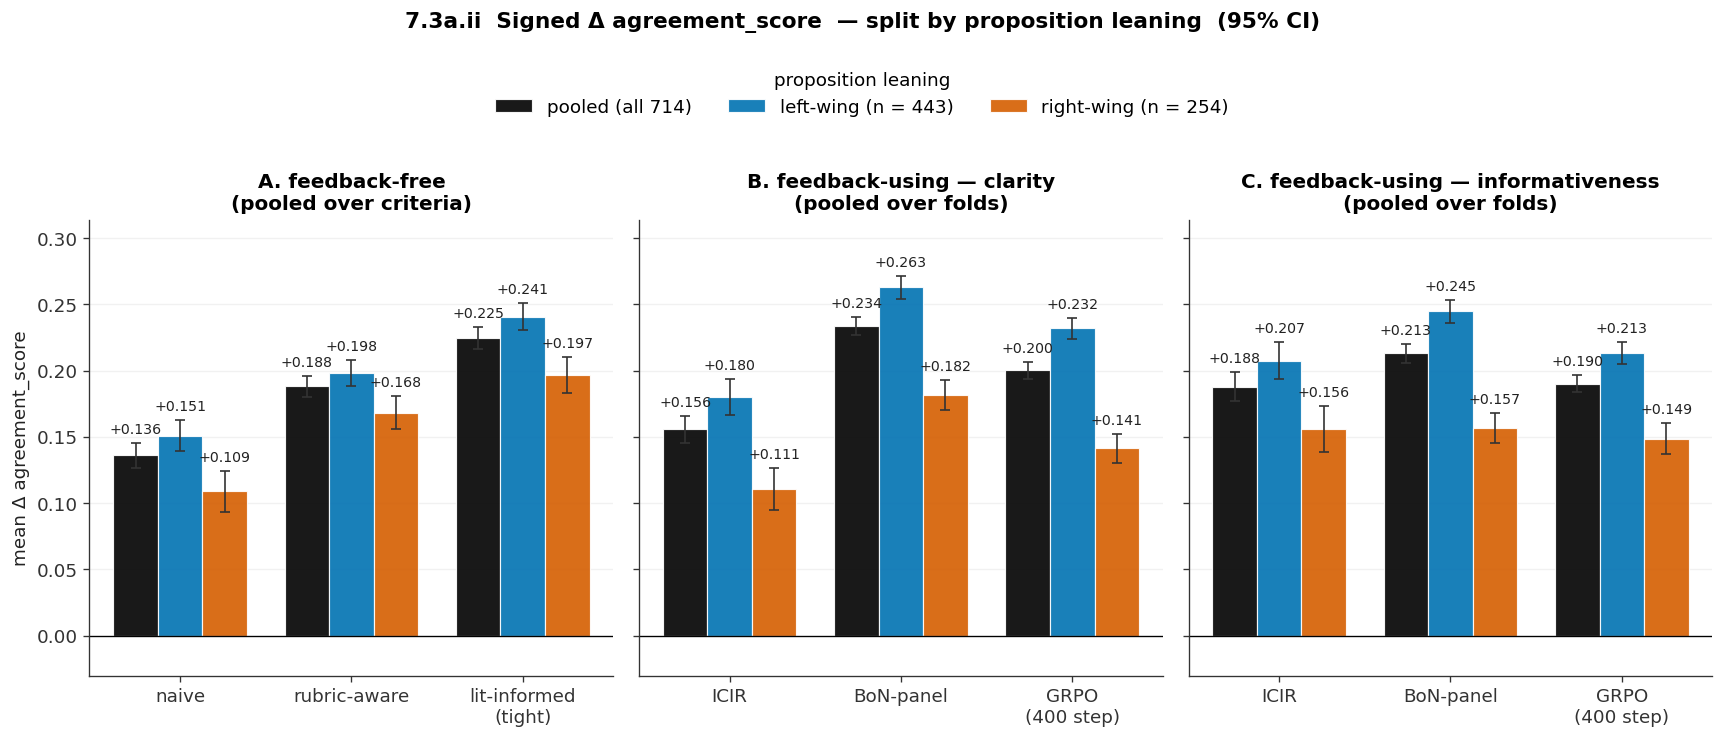

In [20]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
LEANINGS = ['pooled', 'left', 'right']
LEANING_COLOR = {
    'pooled': OKABE_ITO['black'],
    'left': OKABE_ITO['blue'],
    'right': OKABE_ITO['vermilion'],
}
LEANING_LABEL = {
    'pooled': 'pooled (all 714)',
    'left': 'left-wing (n = 443)',
    'right': 'right-wing (n = 254)',
}

fig, axes = plt.subplots(1, 3, figsize=(14.5, 6.0), sharey=True)
axA, axClar, axInf = axes
panel_specs = [
    (axA, 'A. feedback-free\n(pooled over criteria)', signed_ff, methods_ff, None),
    (axClar, 'B. feedback-using — clarity\n(pooled over folds)', signed_fu, methods_fu, 'clarity'),
    (axInf, 'C. feedback-using — informativeness\n(pooled over folds)', signed_fu, methods_fu, 'informativeness'),
]

lean_handles = {}
for ax, title, df, methods, criterion_filter in panel_specs:
    x = np.arange(len(methods))
    width = 0.26
    for i, leaning in enumerate(LEANINGS):
        sub = df[df['leaning'] == leaning].copy()
        if criterion_filter is not None:
            sub = sub[sub['criterion'] == criterion_filter]
        sub = sub.set_index('method').reindex(methods)
        means = sub['mean'].values
        cis = sub['ci95'].values
        bars = ax.bar(x + (i - 1) * width, means, width,
                      yerr=cis, capsize=3,
                      label=LEANING_LABEL[leaning],
                      color=LEANING_COLOR[leaning], alpha=0.9,
                      edgecolor='white', linewidth=0.7,
                      error_kw={'ecolor': '#333333', 'elinewidth': 1})
        _annotate_bars(ax, bars, means, cis, fmt='{:+.3f}', pad=0.005, fontsize=8.5)
        if ax is axA:
            lean_handles[leaning] = bars
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_TICK[m] for m in methods])
    _style_bar_axes(ax,
                    ylabel='mean Δ agreement_score' if ax is axA else None,
                    title=title)

# Asymmetric y-axis: show zero clearly but don't waste vertical space
# on the empty negative region.
ylo = min(ax.get_ylim()[0] for ax in axes)
yhi = max(ax.get_ylim()[1] for ax in axes)
ylo = min(ylo, -0.03)  # ensure zero line is visible with a little slack
yhi = yhi * 1.10
axA.set_ylim(ylo, yhi)

fig.legend([lean_handles[l] for l in LEANINGS],
           [LEANING_LABEL[l] for l in LEANINGS],
           title='proposition leaning',
           loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=3, frameon=False, fontsize=11)
fig.suptitle('7.3a.ii  Signed Δ agreement_score  — split by proposition leaning  (95% CI)',
             y=1.02, fontsize=13, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(FIG_DIR / 'fig7_3a_signed_shift_by_wing.png')
plt.show()

#### 7.3b — Stance-flip rate

% of kept paragraphs (originals with agreement strictly between 0.25 and 0.75 are excluded) whose stance flips. `anti → pro` = rewrite moves from original ≤ 0.25 to rewrite ≥ 0.75; `pro → anti` is the reverse. For feedback-using methods each (paragraph × fold) contributes one observation, so the denominator is 3× the per-fold kept count.

In [21]:
def _flip_summary(g):
    kept = g[g['flip_class'] != 'excluded']
    n_keep = len(kept)
    n_l2h = (kept['flip_class'] == 'flip_low_to_high').sum()
    n_h2l = (kept['flip_class'] == 'flip_high_to_low').sum()
    n_flip = n_l2h + n_h2l
    return pd.Series({
        'pct_flipped': 100 * n_flip / n_keep if n_keep else float('nan'),
        'n_L_to_H': int(n_l2h),
        'n_H_to_L': int(n_h2l),
        'n_kept': int(n_keep),
        'n_excluded': int(len(g) - n_keep),
    })

flip_ff = (agree[agree['method'].isin(FEEDBACK_FREE)]
           .groupby('method').apply(_flip_summary).reset_index())
flip_ff = flip_ff.sort_values('pct_flipped', ascending=False).reset_index(drop=True)
print('Feedback-free — stance-flip rate (pooled across criteria):')
print(flip_ff.round(2).to_string(index=False))

flip_fu = (agree[agree['method'].isin(FEEDBACK_USING)]
           .groupby(['method', 'rewrite_criterion']).apply(_flip_summary).reset_index()
           .rename(columns={'rewrite_criterion': 'criterion'}))
flip_fu = flip_fu.sort_values(['criterion', 'pct_flipped'], ascending=[True, False]).reset_index(drop=True)
print()
print('Feedback-using — stance-flip rate (pooled over folds):')
print(flip_fu.round(2).to_string(index=False))

Feedback-free — stance-flip rate (pooled across criteria):
            method  pct_flipped  n_L_to_H  n_H_to_L  n_kept  n_excluded
lit_informed_tight        20.23     616.0       8.0  3084.0      1200.0
      rubric_aware        15.99     490.0       3.0  3084.0      1200.0
             naive         8.56     128.0       4.0  1542.0       600.0

Feedback-using — stance-flip rate (pooled over folds):
      method       criterion  pct_flipped  n_L_to_H  n_H_to_L  n_kept  n_excluded
   bon_panel         clarity        21.77     990.0      17.0  4626.0      1800.0
grpo_400step         clarity        16.21     728.0      22.0  4626.0      1800.0
        icir         clarity        11.93     182.0       2.0  1542.0       600.0
   bon_panel informativeness        20.58     924.0      28.0  4626.0      1800.0
grpo_400step informativeness        16.21     708.0      42.0  4626.0      1800.0
        icir informativeness        15.05     230.0       2.0  1542.0       600.0


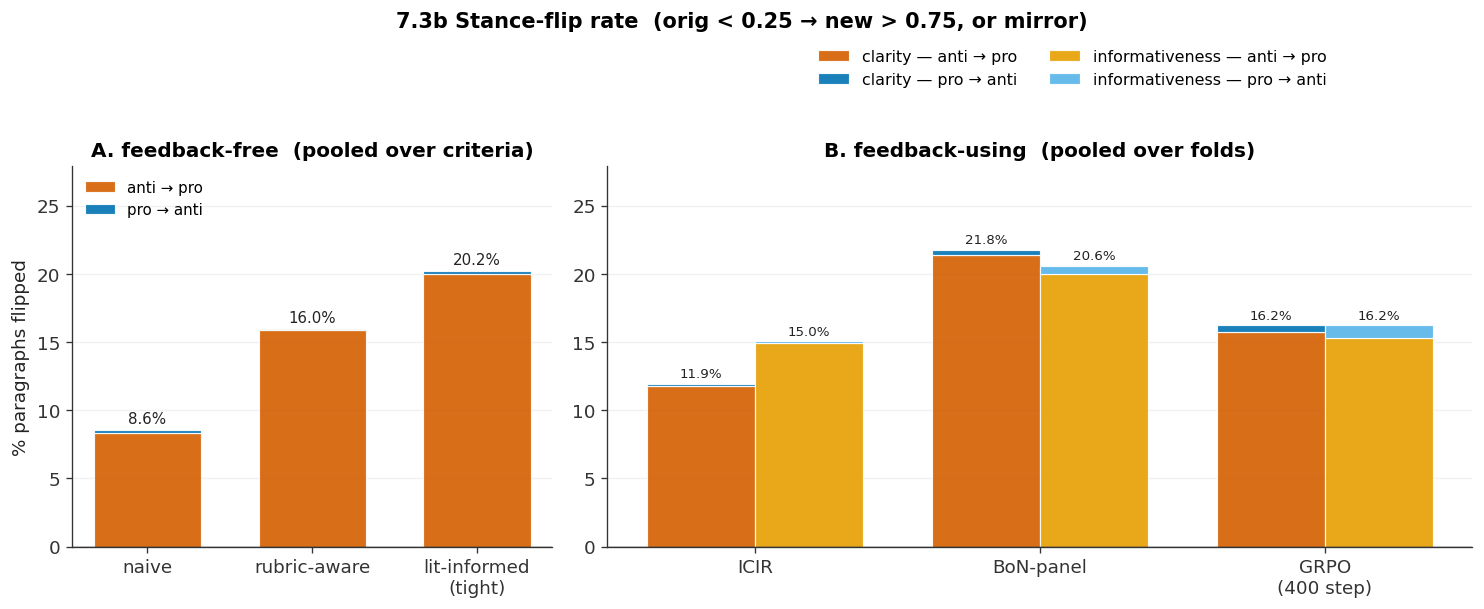

In [22]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9),
                         gridspec_kw={'width_ratios': [1, 1.8]})

# Panel A.
axA = axes[0]
sub = flip_ff.set_index('method').reindex(methods_ff)
x = np.arange(len(methods_ff))
n_keep = sub['n_kept'].values
pct_L2H = 100 * sub['n_L_to_H'].values / n_keep
pct_H2L = 100 * sub['n_H_to_L'].values / n_keep
ff_L2H = axA.bar(x, pct_L2H, 0.65, color=OKABE_ITO['vermilion'], alpha=0.9,
                 edgecolor='white', linewidth=0.7, label='anti → pro')
ff_H2L = axA.bar(x, pct_H2L, 0.65, bottom=pct_L2H, color=OKABE_ITO['blue'], alpha=0.9,
                 edgecolor='white', linewidth=0.7, label='pro → anti')
for xi, total in zip(x, pct_L2H + pct_H2L):
    axA.text(xi, total + 0.25, f'{total:.1f}%', ha='center', va='bottom',
             fontsize=9, color='#222222')
axA.set_xticks(x)
axA.set_xticklabels([METHOD_TICK[m] for m in methods_ff])
_style_bar_axes(axA,
                ylabel='% paragraphs flipped',
                title='A. feedback-free  (pooled over criteria)')

# Panel B.
axB = axes[1]
x = np.arange(len(methods_fu))
width = 0.38
colour_L2H = {'clarity': OKABE_ITO['vermilion'], 'informativeness': OKABE_ITO['orange']}
colour_H2L = {'clarity': OKABE_ITO['blue'], 'informativeness': OKABE_ITO['sky']}
legend_handles = []
legend_labels = []
for i, crit in enumerate(criteria):
    sub = (flip_fu[flip_fu['criterion'] == crit]
           .set_index('method').reindex(methods_fu))
    n_keep = sub['n_kept'].values
    pct_L2H = 100 * sub['n_L_to_H'].values / n_keep
    pct_H2L = 100 * sub['n_H_to_L'].values / n_keep
    offset = (i - 0.5) * width
    bL = axB.bar(x + offset, pct_L2H, width, color=colour_L2H[crit], alpha=0.9,
                 edgecolor='white', linewidth=0.7)
    bH = axB.bar(x + offset, pct_H2L, width, bottom=pct_L2H,
                 color=colour_H2L[crit], alpha=0.9,
                 edgecolor='white', linewidth=0.7)
    legend_handles += [bL, bH]
    legend_labels += [f'{crit} — anti → pro', f'{crit} — pro → anti']
    for xi, total in zip(x + offset, pct_L2H + pct_H2L):
        axB.text(xi, total + 0.25, f'{total:.1f}%', ha='center', va='bottom',
                 fontsize=8, color='#222222')

axB.set_xticks(x)
axB.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
_style_bar_axes(axB,
                title='B. feedback-using  (pooled over folds)')

ymax = max(axA.get_ylim()[1], axB.get_ylim()[1]) * 1.22
for ax in axes:
    ax.set_ylim(0, ymax)

# Composite legend above panels.
axA.legend(loc='upper left', frameon=False, fontsize=9)
fig.legend(legend_handles, legend_labels,
           loc='upper center', bbox_to_anchor=(0.72, 0.99),
           ncol=2, frameon=False, fontsize=9.5)
fig.suptitle('7.3b Stance-flip rate  (orig < 0.25 → new > 0.75, or mirror)',
             y=1.03, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig(FIG_DIR / 'fig7_3b_stance_flip.png')
plt.show()

## 8 — Method comparison with rewriter as covariate

Rewriter (the small base model) and method (the prompting / RL strategy) co-vary.
This section keeps both axes explicit and reports counterfactual differences.

**Scope (this section only):**
- Methods: drop `icir`, `*_q95only`, `grpo_g8_halfdata_cont`, `*_single`, `bon_candidate`. Kept: `original`, `naive`, `rubric_aware`, `lit_informed_tight`, `bon_panel`, `grpo_400step`, `grpo_nli_400step`.
- Judges (OOS = main outcome variable): `mistral7b`, `phi35mini`, `cmdr7b`.
- Judges (in-sample, used in plots only): `qwen95b`, `llama8b`, `gemma9b`.
- Both `clarity` and `informativeness` criteria pooled.

Excluded data is *not deleted*; rows are filtered in-memory.

### 8.0 — Setup

In [23]:
import statsmodels.formula.api as smf
from patsy import dmatrix

S8_IN_SAMPLE_JUDGES = ['judge_qwen95b', 'judge_llama8b', 'judge_gemma9b']
S8_OOS_JUDGES       = ['judge_mistral7b', 'judge_phi35mini', 'judge_cmdr7b']
S8_ALL_JUDGES       = S8_IN_SAMPLE_JUDGES + S8_OOS_JUDGES
S8_PANEL = {**{j: 'in_sample' for j in S8_IN_SAMPLE_JUDGES},
            **{j: 'oos'       for j in S8_OOS_JUDGES}}

S8_EXCLUDED_METHODS = {
    'icir', 'icir_q95only',
    'bon_panel_q95only', 'grpo_q95only', 'grpo_g8_halfdata_cont',
    'bon_panel_single', 'grpo_nli_single',
    'bon_candidate',  # pre-selection candidate pool, not a final method
}
S8_METHOD_ORDER = ['original', 'naive', 'rubric_aware', 'lit_informed_tight',
                   'bon_panel', 'grpo_400step', 'grpo_nli_400step']

S8_REWRITER_LABEL = {
    'LiquidAI/LFM2.5-1.2B-Instruct': 'LFM2.5-1.2B',
    'Qwen/Qwen2.5-1.5B-Instruct':    'Qwen2.5-1.5B',
    'google/gemma-3-1b-it':          'gemma-3-1B',
}
S8_REWRITER_ORDER = ['LFM2.5-1.2B', 'Qwen2.5-1.5B', 'gemma-3-1B']

_keep_methods_sql = ','.join(f"'{m}'" for m in S8_METHOD_ORDER)
_all_judges_sql   = ','.join(f"'{j}'" for j in S8_ALL_JUDGES)

# Long format: one row per (rewrite, judge, criterion).
s8_scores = pd.read_sql_query(f'''
    SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
           ar.rewriter_model, ar.criterion AS rewrite_criterion,
           ajs.judge_slug, ajs.criterion AS judge_criterion, ajs.score
    FROM   attack_rewrites ar
    JOIN   attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
    WHERE  ar.method IN ({_keep_methods_sql})
      AND  ajs.judge_slug IN ({_all_judges_sql})
''', conn)
s8_scores['rewriter'] = s8_scores['rewriter_model'].map(S8_REWRITER_LABEL).fillna('—')
s8_scores['panel']    = s8_scores['judge_slug'].map(S8_PANEL)

# Per-rewrite metric tables (NLI + agreement-score).
s8_agree = pd.read_sql_query('SELECT rewrite_id, score AS agreement FROM attack_agreement_scores', conn)
s8_nli   = pd.read_sql_query('SELECT rewrite_id, nli_fwd, nli_bwd FROM attack_nli_scores', conn)

print(f"rows: {len(s8_scores):,}   unique rewrites: {s8_scores.rewrite_id.nunique():,}   clusters: {s8_scores.source_doc_id.nunique()}")
print('judge × method coverage (should be balanced):')
display(s8_scores.groupby(['method', 'judge_slug']).size().unstack(fill_value=0))

rows: 612,852   unique rewrites: 51,071   clusters: 1805
judge × method coverage (should be balanced):


judge_slug,judge_cmdr7b,judge_gemma9b,judge_llama8b,judge_mistral7b,judge_phi35mini,judge_qwen95b
method,,,,,,
bon_panel,25704,25704,25704,25704,25704,25704
grpo_400step,25704,25704,25704,25704,25704,25704
grpo_nli_400step,25704,25704,25704,25704,25704,25704
lit_informed_tight,8568,8568,8568,8568,8568,8568
naive,4284,4284,4284,4284,4284,4284
original,3610,3610,3610,3610,3610,3610
rubric_aware,8568,8568,8568,8568,8568,8568


### 8.1 — Table 1: methods × metrics (OOS judge mean, averaged over rewriters & criteria)

In [24]:
# OOS-only judge score per rewrite (mean over 3 OOS judges × 2 criteria = 6 cells)
_oos = s8_scores[s8_scores['panel'] == 'oos']
_oos_per_rewrite = _oos.groupby('rewrite_id')['score'].mean().rename('judge_OOS')

_meta = s8_scores[['rewrite_id', 'method', 'rewriter']].drop_duplicates()
s8_per_rewrite = (_meta.merge(_oos_per_rewrite, on='rewrite_id')
                       .merge(s8_agree, on='rewrite_id', how='left')
                       .merge(s8_nli,   on='rewrite_id', how='left'))

s8_table1 = (s8_per_rewrite.groupby('method')
             .agg(judge_OOS=('judge_OOS', 'mean'),
                  agreement=('agreement', 'mean'),
                  nli_fwd  =('nli_fwd',   'mean'),
                  nli_bwd  =('nli_bwd',   'mean'),
                  n_rewrites=('rewrite_id', 'count'))
             .reindex(S8_METHOD_ORDER))
s8_table1.round(3)

,judge_OOS,agreement,nli_fwd,nli_bwd,n_rewrites
method,,,,,
original,54.465,0.523,0.989,0.989,1805
naive,72.586,0.665,0.493,0.637,2142
rubric_aware,73.896,0.717,0.424,0.539,4284
lit_informed_tight,77.989,0.753,0.357,0.495,4284
bon_panel,80.665,0.752,0.307,0.420,12852
grpo_400step,81.184,0.724,0.389,0.444,12852
grpo_nli_400step,73.468,0.562,0.813,0.924,12852


### 8.2 — Table 2: methods × rewriter × metrics

In [25]:
s8_table2 = (s8_per_rewrite.groupby(['method', 'rewriter'])
             .agg(judge_OOS=('judge_OOS', 'mean'),
                  agreement=('agreement', 'mean'),
                  nli_fwd  =('nli_fwd',   'mean'),
                  nli_bwd  =('nli_bwd',   'mean'),
                  n        =('rewrite_id', 'count'))
             .reset_index())
s8_table2['method']   = pd.Categorical(s8_table2['method'],   categories=S8_METHOD_ORDER, ordered=True)
s8_table2['rewriter'] = pd.Categorical(s8_table2['rewriter'], categories=S8_REWRITER_ORDER + ['—'], ordered=True)
s8_table2 = s8_table2.sort_values(['method', 'rewriter']).reset_index(drop=True)
s8_table2.round(3)

,method,rewriter,judge_OOS,agreement,nli_fwd,nli_bwd,n
0,original,—,54.465,0.523,0.989,0.989,1805
1,naive,LFM2.5-1.2B,72.256,0.732,0.389,0.544,714
2,naive,Qwen2.5-1.5B,67.341,0.586,0.644,0.802,714
3,naive,gemma-3-1B,78.160,0.675,0.447,0.565,714
4,rubric_aware,LFM2.5-1.2B,74.331,0.809,0.227,0.383,1428
5,rubric_aware,Qwen2.5-1.5B,68.680,0.611,0.639,0.784,1428
6,rubric_aware,gemma-3-1B,78.676,0.729,0.406,0.451,1428
7,lit_informed_tight,LFM2.5-1.2B,79.981,0.797,0.224,0.448,1428
8,lit_informed_tight,Qwen2.5-1.5B,72.531,0.685,0.529,0.628,1428
9,lit_informed_tight,gemma-3-1B,81.455,0.777,0.318,0.410,1428


### 8.3 — Score distributions: human-written originals vs. rewrites

For each judge (3 in-sample + 3 OOS), overlay the histogram of original
vs. rewrite scores. Faceted on a 6 × 2 grid (judge × criterion).
Rewrites pool all in-scope methods × rewriters.

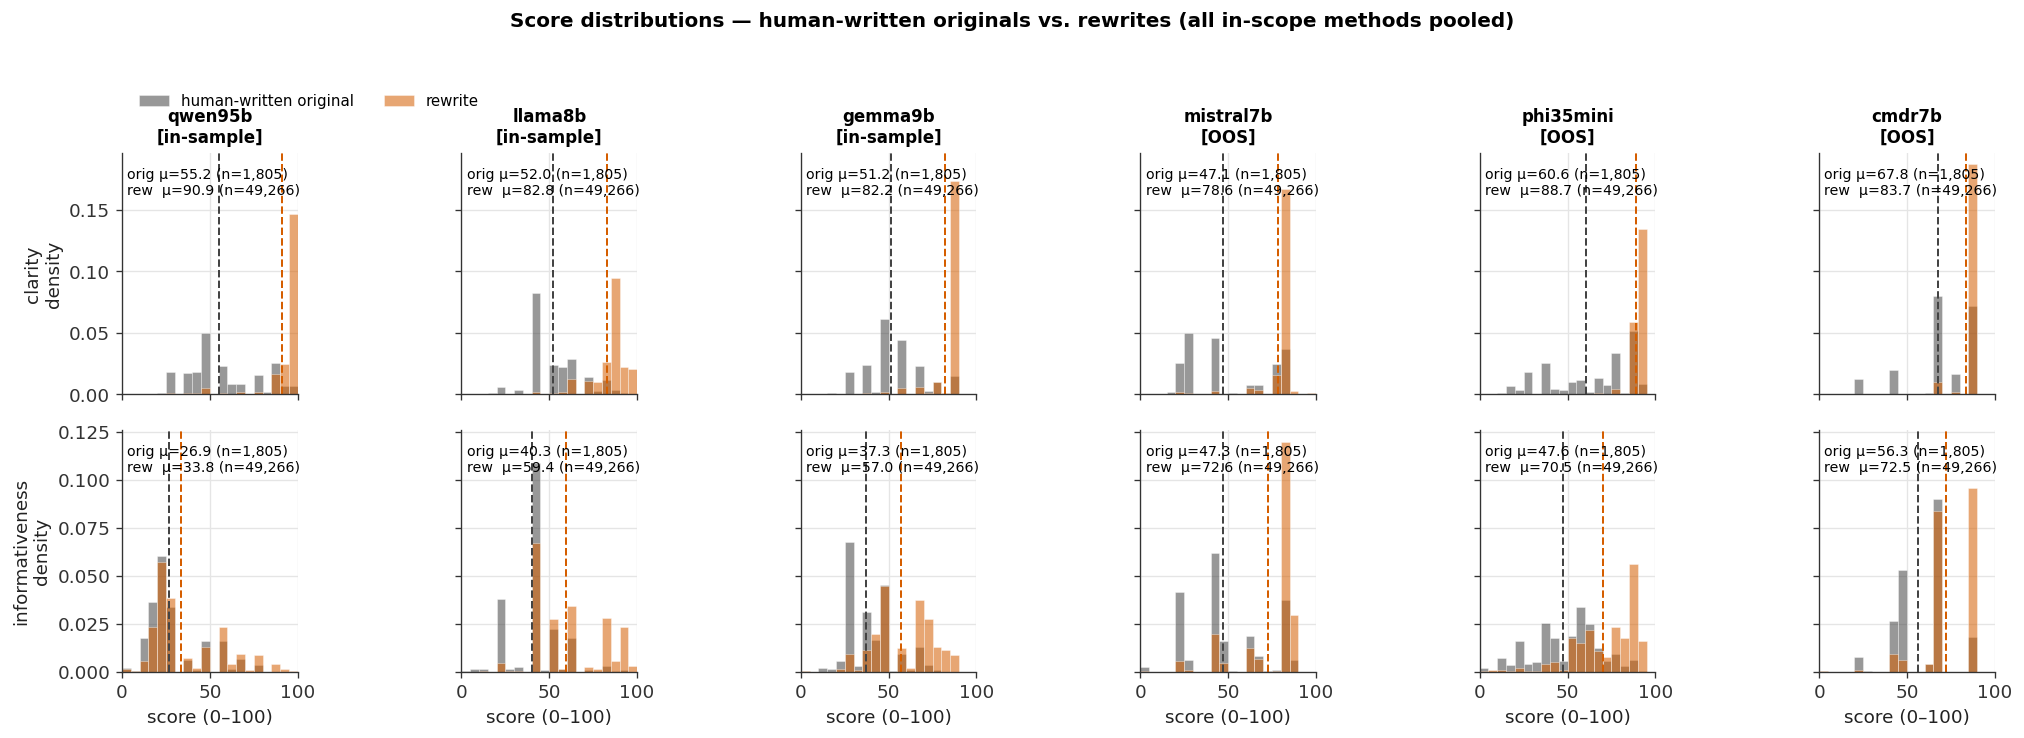

In [26]:
_hist = s8_scores.copy()
_hist['kind'] = np.where(_hist['method'] == 'original', 'human-written original', 'rewrite (any method)')

CRITERIA = ['clarity', 'informativeness']
JUDGE_ORDER_8 = S8_IN_SAMPLE_JUDGES + S8_OOS_JUDGES
COLOR_ORIG = '#444444'
COLOR_REW  = OKABE_ITO['vermilion']
BINS = np.arange(0, 105, 5)

fig, axes = plt.subplots(len(CRITERIA), len(JUDGE_ORDER_8), figsize=(17, 6.0),
                         sharex=True, sharey='row')
for i, crit in enumerate(CRITERIA):
    for j, judge in enumerate(JUDGE_ORDER_8):
        ax = axes[i, j]
        d = _hist[(_hist['judge_criterion'] == crit) & (_hist['judge_slug'] == judge)]
        orig = d.loc[d['kind'] == 'human-written original', 'score'].to_numpy()
        rew  = d.loc[d['kind'] == 'rewrite (any method)',   'score'].to_numpy()
        ax.hist(orig, bins=BINS, density=True, color=COLOR_ORIG, alpha=0.55,
                edgecolor='white', linewidth=0.4, label='human-written original')
        ax.hist(rew,  bins=BINS, density=True, color=COLOR_REW,  alpha=0.55,
                edgecolor='white', linewidth=0.4, label='rewrite')
        ax.axvline(orig.mean(), color=COLOR_ORIG, linestyle='--', linewidth=1.2)
        ax.axvline(rew.mean(),  color=COLOR_REW,  linestyle='--', linewidth=1.2)
        ax.text(0.03, 0.94,
                f'orig μ={orig.mean():.1f} (n={len(orig):,})\n'
                f'rew  μ={rew.mean():.1f} (n={len(rew):,})',
                transform=ax.transAxes, ha='left', va='top', fontsize=8.5)
        if i == 0:
            tag = 'in-sample' if judge in S8_IN_SAMPLE_JUDGES else 'OOS'
            ax.set_title(f"{judge.replace('judge_', '')}\n[{tag}]", fontsize=10)
        if i == len(CRITERIA) - 1:
            ax.set_xlabel('score (0–100)')
        if j == 0:
            ax.set_ylabel(f'{crit}\ndensity', rotation=90)
        ax.set_xlim(0, 100)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.02, 1.30),
                  ncol=2, frameon=False, fontsize=9)
fig.suptitle('Score distributions — human-written originals vs. rewrites '
             '(all in-scope methods pooled)', y=1.02, fontsize=12, fontweight='semibold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_s8_dists_orig_vs_rewrite.png')
plt.show()

### 8.4 — Regression: OOS score vs. method × rewriter

Long-format model on `(rewrite, judge, criterion)` observations:

\[
\text{score} = \beta_0 + \beta_m \cdot \text{method} + \beta_r \cdot \text{rewriter} + \beta_{m \times r} \cdot \text{method × rewriter} + \gamma_j \cdot \text{judge} + \delta_c \cdot \text{criterion} + \varepsilon
\]

- Outcome restricted to **OOS judges** (`mistral7b`, `phi35mini`, `cmdr7b`).
- `original` is dropped from the regression (no rewriter); use Table 1 for that baseline.
- Reference cell: `naive` rewriter `Qwen2.5-1.5B`. Cluster-robust SE on `source_doc_id`.

Counterfactual reported: **predicted mean OOS score per method, holding the rewriter
mix uniform across the three small models** and marginalising over judges/criteria.
This is what each method's expected score *would be* if every method used the same
rewriter portfolio — which removes the model-quality confound.

In [27]:
s8_reg = s8_scores[(s8_scores['panel'] == 'oos') &
                   (s8_scores['method'] != 'original') &
                   (s8_scores['rewriter'].isin(S8_REWRITER_ORDER))].copy()
s8_reg['method']   = pd.Categorical(
    s8_reg['method'],
    categories=['naive'] + [m for m in S8_METHOD_ORDER if m not in ('original', 'naive')])
s8_reg['rewriter'] = pd.Categorical(s8_reg['rewriter'],
                                    categories=['Qwen2.5-1.5B', 'LFM2.5-1.2B', 'gemma-3-1B'])

s8_mod = smf.ols(
    'score ~ C(method, Treatment("naive")) * C(rewriter, Treatment("Qwen2.5-1.5B"))'
    ' + C(judge_slug) + C(judge_criterion)', data=s8_reg)
s8_res = s8_mod.fit(cov_type='cluster', cov_kwds={'groups': s8_reg['source_doc_id']})
print(f'rows fit: {len(s8_reg):,}   clusters: {s8_reg.source_doc_id.nunique()}   R² = {s8_res.rsquared:.3f}')

rows fit: 295,596   clusters: 714   R² = 0.278


In [28]:
# Counterfactual cell grid: every (method, rewriter, judge, criterion).
# Uniform mix across rewriters and OOS judges/criteria.
_methods_reg = list(s8_reg['method'].cat.categories)
_grid = pd.MultiIndex.from_product(
    [_methods_reg, S8_REWRITER_ORDER, S8_OOS_JUDGES, ['clarity', 'informativeness']],
    names=['method', 'rewriter', 'judge_slug', 'judge_criterion']).to_frame(index=False)
_grid['method']   = pd.Categorical(_grid['method'],   categories=_methods_reg)
_grid['rewriter'] = pd.Categorical(_grid['rewriter'], categories=['Qwen2.5-1.5B', 'LFM2.5-1.2B', 'gemma-3-1B'])

_X = np.asarray(dmatrix(s8_res.model.data.design_info, _grid, return_type='matrix'))
_grid['pred'] = _X @ s8_res.params.values

s8_cf_method = (_grid.groupby('method', observed=True)['pred'].mean()
                .reindex([m for m in S8_METHOD_ORDER if m in _methods_reg])
                .rename('counterfactual_mean_OOS'))
print('Counterfactual mean OOS score per method (uniform rewriter mix):')
print(s8_cf_method.round(3).to_string())

s8_cf_method_x_rewriter = (_grid.groupby(['method', 'rewriter'], observed=True)['pred']
                           .mean().unstack()
                           .reindex([m for m in S8_METHOD_ORDER if m in _methods_reg]))
print('\nCounterfactual mean OOS score per (method, rewriter):')
display(s8_cf_method_x_rewriter.round(2))

Counterfactual mean OOS score per method (uniform rewriter mix):
method
naive                 72.586
rubric_aware          73.896
lit_informed_tight    77.989
bon_panel             80.665
grpo_400step          81.184
grpo_nli_400step      73.468

Counterfactual mean OOS score per (method, rewriter):


rewriter,Qwen2.5-1.5B,LFM2.5-1.2B,gemma-3-1B
method,,,
naive,67.34,72.26,78.16
rubric_aware,68.68,74.33,78.68
lit_informed_tight,72.53,79.98,81.46
bon_panel,78.23,81.28,82.48
grpo_400step,80.16,82.79,80.60
grpo_nli_400step,71.47,74.59,74.34


In [29]:
# Pairwise differences with cluster-robust SE.
_cov = s8_res.cov_params().values

def _L_for(method):
    mask = (_grid['method'] == method).values
    return _X[mask].mean(axis=0)

def _diff_with_se(m_hi, m_lo):
    L = _L_for(m_hi) - _L_for(m_lo)
    est = float(L @ s8_res.params.values)
    se  = float(np.sqrt(L @ _cov @ L))
    return est, se

# Δ vs naive (rich version)
_rows = []
for m in _methods_reg:
    if m == 'naive':
        continue
    est, se = _diff_with_se(m, 'naive')
    _rows.append({'method': m, 'Δ_vs_naive': est, 'se': se,
                  'ci_lo': est - 1.96 * se, 'ci_hi': est + 1.96 * se,
                  't': est / se})
s8_diff_vs_naive = pd.DataFrame(_rows)
print('Δ in counterfactual mean OOS score vs `naive` (95% cluster-robust CIs):')
print(s8_diff_vs_naive.round(3).to_string(index=False))

# Full pairwise matrix (point estimates only, for at-a-glance)
_mat = pd.DataFrame(index=_methods_reg, columns=_methods_reg, dtype=float)
for mi in _methods_reg:
    for mj in _methods_reg:
        if mi == mj:
            continue
        est, _ = _diff_with_se(mi, mj)
        _mat.loc[mi, mj] = est
s8_pairwise_diff = _mat.reindex([m for m in S8_METHOD_ORDER if m in _methods_reg],
                                columns=[m for m in S8_METHOD_ORDER if m in _methods_reg])
print('\nFull pairwise difference matrix (Δ = row − col, point estimate):')
display(s8_pairwise_diff.round(2))

Δ in counterfactual mean OOS score vs `naive` (95% cluster-robust CIs):
            method  Δ_vs_naive    se  ci_lo  ci_hi      t
      rubric_aware       1.310 0.170  0.976  1.644  7.684
lit_informed_tight       5.403 0.201  5.010  5.796 26.942
         bon_panel       8.080 0.233  7.623  8.536 34.668
      grpo_400step       8.598 0.214  8.178  9.018 40.141
  grpo_nli_400step       0.883 0.184  0.522  1.243  4.793

Full pairwise difference matrix (Δ = row − col, point estimate):


,naive,rubric_aware,lit_informed_tight,bon_panel,grpo_400step,grpo_nli_400step
naive,NaN,-1.31,-5.40,-8.08,-8.60,-0.88
rubric_aware,1.31,NaN,-4.09,-6.77,-7.29,0.43
lit_informed_tight,5.40,4.09,NaN,-2.68,-3.19,4.52
bon_panel,8.08,6.77,2.68,NaN,-0.52,7.20
grpo_400step,8.60,7.29,3.19,0.52,NaN,7.72
grpo_nli_400step,0.88,-0.43,-4.52,-7.20,-7.72,NaN


### 8.5 — Flip rate (strict opposite extreme)

Of the source paragraphs with original `agreement_score ≤ 0.25` or `≥ 0.75`,
what % have their rewrite cross all the way to the *opposite* extreme bucket?

- source ≤ 0.25 ⇒ flips iff rewrite ≥ 0.75
- source ≥ 0.75 ⇒ flips iff rewrite ≤ 0.25
- source ∈ (0.25, 0.75) excluded from the denominator (no extreme stance to flip from)

In [30]:
# Original agreement per source paragraph (one row per source_doc_id).
_orig_agree = pd.read_sql_query('''
    SELECT ar.source_doc_id, AVG(aas.score) AS orig_agree
    FROM attack_rewrites ar
    JOIN attack_agreement_scores aas ON aas.rewrite_id = ar.rewrite_id
    WHERE ar.method = 'original'
    GROUP BY ar.source_doc_id''', conn)

# Rewrite agreement, in-scope methods only (drop original since it's the baseline).
_rew_agree = pd.read_sql_query(f'''
    SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.rewriter_model,
           ar.criterion AS rew_criterion, aas.score AS rew_agree
    FROM attack_rewrites ar
    JOIN attack_agreement_scores aas ON aas.rewrite_id = ar.rewrite_id
    WHERE ar.method IN ({_keep_methods_sql}) AND ar.method != 'original' ''', conn)
_rew_agree['rewriter'] = _rew_agree['rewriter_model'].map(S8_REWRITER_LABEL)

# Proposition leaning from paul_data.
_lean_docs  = pd.read_csv('../paul_data/prepared/documents.csv',
                          usecols=['document_id', 'proposition_id']).rename(
                              columns={'document_id': 'source_doc_id'})
_lean_props = pd.read_csv('../paul_data/main_phase_1/propositions.csv',
                          usecols=['proposition_id', 'proposition_leaning'])
_lean = _lean_docs.merge(_lean_props, on='proposition_id')

s8_agree_full = (_rew_agree.merge(_orig_agree, on='source_doc_id')
                          .merge(_lean[['source_doc_id', 'proposition_id', 'proposition_leaning']],
                                 on='source_doc_id'))
print(f'rows: {len(s8_agree_full):,}   leaning split (40 props): '
      + ', '.join(f'{k}={v}' for k, v in
                  _lean_props.merge(_lean_docs[['proposition_id']].drop_duplicates(),
                                    on='proposition_id')['proposition_leaning'].value_counts().items()))

S8_FLIP_LO, S8_FLIP_HI = 0.25, 0.75

def _classify_flip(o, n):
    if S8_FLIP_LO < o < S8_FLIP_HI:           return 'excluded_mid'
    if o <= S8_FLIP_LO and n >= S8_FLIP_HI:   return 'flip_low_to_high'
    if o >= S8_FLIP_HI and n <= S8_FLIP_LO:   return 'flip_high_to_low'
    return 'not_flipped'

s8_agree_full['flip_class'] = [_classify_flip(o, n)
                               for o, n in zip(s8_agree_full['orig_agree'],
                                               s8_agree_full['rew_agree'])]

def _flip_summary(g):
    kept = g[g['flip_class'] != 'excluded_mid']
    n_keep = len(kept)
    n_flip = kept['flip_class'].isin(['flip_low_to_high', 'flip_high_to_low']).sum()
    return pd.Series({
        'flip_rate_%':    100 * n_flip / n_keep if n_keep else np.nan,
        'n_kept':         int(n_keep),
        'n_flipped':      int(n_flip),
        'n_excluded_mid': int(len(g) - n_keep),
    })

s8_flip_by_method = (s8_agree_full.groupby('method').apply(_flip_summary)
                     .reindex([m for m in S8_METHOD_ORDER if m != 'original']))
print('\nFlip rate by method (pooled across rewriters & criteria):')
print(s8_flip_by_method.round(2).to_string())

s8_flip_by_method_rw = (s8_agree_full.dropna(subset=['rewriter'])
                        .groupby(['method', 'rewriter']).apply(_flip_summary))
print('\nFlip rate by method × rewriter:')
print(s8_flip_by_method_rw.round(2).to_string())

rows: 49,266   leaning split (40 props): left=46, right=46, neither=8

Flip rate by method (pooled across rewriters & criteria):
                    flip_rate_%  n_kept  n_flipped  n_excluded_mid
method                                                            
naive                      8.56  1542.0      132.0           600.0
rubric_aware              15.99  3084.0      493.0          1200.0
lit_informed_tight        20.23  3084.0      624.0          1200.0
bon_panel                 21.17  9252.0     1959.0          3600.0
grpo_400step              16.21  9252.0     1500.0          3600.0
grpo_nli_400step           0.94  9252.0       87.0          3600.0

Flip rate by method × rewriter:
                                 flip_rate_%  n_kept  n_flipped  n_excluded_mid
method             rewriter                                                    
bon_panel          LFM2.5-1.2B         25.52  3084.0      787.0          1200.0
                   Qwen2.5-1.5B        14.56  3084.0      449.

### 8.6 — Left-wing shift

40-prop leaning split (paul_data labels): **25 left, 14 right, 1 neither (id 173,
autonomous vehicles)**. Per agreement, prop 173 is dropped from this metric only.

Define `left_wing_agreement` per (paragraph, leaning):
- left-leaning prop: `lw = agreement_score`
- right-leaning prop: `lw = 1 − agreement_score`

Then the shift is `mean(rewrite_lw) − mean(orig_lw)`. Positive ⇒ rewrites
push the stance leftward on average; negative ⇒ rightward.

Because props are unbalanced (25 vs 14), the pooled mean weights left-leaning
paragraphs more heavily. The split-by-leaning sub-table shows the per-side
movement separately so this is transparent.

In [31]:
s8_lw = s8_agree_full[s8_agree_full['proposition_leaning'].isin(['left', 'right'])].copy()
print(f'dropped {(s8_agree_full["proposition_leaning"] == "neither").sum():,} rows from prop 173 ("neither")')

def _to_lw(score, leaning):
    return score if leaning == 'left' else 1.0 - score

s8_lw['orig_lw']  = [_to_lw(s, l) for s, l in zip(s8_lw['orig_agree'],  s8_lw['proposition_leaning'])]
s8_lw['rew_lw']   = [_to_lw(s, l) for s, l in zip(s8_lw['rew_agree'],   s8_lw['proposition_leaning'])]
s8_lw['shift_lw'] = s8_lw['rew_lw'] - s8_lw['orig_lw']

def _lw_summary(g):
    return pd.Series({
        'orig_lw_mean':  g['orig_lw'].mean(),
        'rew_lw_mean':   g['rew_lw'].mean(),
        'lw_shift_mean': g['shift_lw'].mean(),
        'lw_shift_se':   g['shift_lw'].std(ddof=1) / np.sqrt(len(g)),
        'n':             int(len(g)),
    })

print('\nLeft-wing shift by method (pooled):')
s8_lw_by_method = (s8_lw.groupby('method').apply(_lw_summary)
                   .reindex([m for m in S8_METHOD_ORDER if m != 'original']))
print(s8_lw_by_method.round(4).to_string())

print('\nLeft-wing shift by method × proposition leaning:')
s8_lw_by_leaning = s8_lw.groupby(['method', 'proposition_leaning']).apply(_lw_summary)
print(s8_lw_by_leaning.round(4).to_string())

print('\nLeft-wing shift by method × rewriter:')
s8_lw_by_rewriter = s8_lw.dropna(subset=['rewriter']).groupby(['method', 'rewriter']).apply(_lw_summary)
print(s8_lw_by_rewriter.round(4).to_string())

dropped 1,173 rows from prop 173 ("neither")

Left-wing shift by method (pooled):
                    orig_lw_mean  rew_lw_mean  lw_shift_mean  lw_shift_se        n
method                                                                            
naive                     0.5463       0.6026         0.0563       0.0056   2091.0
rubric_aware              0.5463       0.6108         0.0645       0.0048   4182.0
lit_informed_tight        0.5463       0.6277         0.0813       0.0053   4182.0
bon_panel                 0.5463       0.6459         0.0996       0.0031  12546.0
grpo_400step              0.5463       0.6349         0.0885       0.0029  12546.0
grpo_nli_400step          0.5463       0.5651         0.0188       0.0011  12546.0

Left-wing shift by method × proposition leaning:
                                        orig_lw_mean  rew_lw_mean  lw_shift_mean  lw_shift_se       n
method             proposition_leaning                                                               


                                 orig_lw_mean  rew_lw_mean  lw_shift_mean  lw_shift_se       n
method             rewriter                                                                   
bon_panel          LFM2.5-1.2B         0.5463       0.6470         0.1006       0.0058  4182.0
                   Qwen2.5-1.5B        0.5463       0.6396         0.0932       0.0045  4182.0
                   gemma-3-1B          0.5463       0.6512         0.1049       0.0057  4182.0
grpo_400step       LFM2.5-1.2B         0.5463       0.6424         0.0960       0.0051  4182.0
                   Qwen2.5-1.5B        0.5463       0.6297         0.0833       0.0049  4182.0
                   gemma-3-1B          0.5463       0.6325         0.0862       0.0049  4182.0
grpo_nli_400step   LFM2.5-1.2B         0.5463       0.5704         0.0241       0.0019  4182.0
                   Qwen2.5-1.5B        0.5463       0.5555         0.0091       0.0014  4182.0
                   gemma-3-1B          0.5463     

### 8.7 — NLI-distance-stratified original/rewrite samples

5 (original, rewrite) pairs at each target value of mean NLI = (`nli_fwd` + `nli_bwd`) / 2.
Targets: 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90.

Window: `target ± 0.01`; if a band is too sparse, fall back to the 5 nearest by distance.
Sampling is seeded per-target for reproducibility.

**Note on the average vs. the components:** mean NLI hides asymmetric cases.
A pair with `fwd ≈ 0.97`, `bwd ≈ 0.03` (the rewrite entails the original but not vice-versa
— rewrite is *broader*) and one with `fwd ≈ 0.03`, `bwd ≈ 0.97` (rewrite is *narrower*)
both land at mean ≈ 0.50 but mean very different things. Both `fwd` and `bwd` are printed
alongside the average so this is visible.

In [32]:
S8_NLI_TARGETS = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
S8_NLI_TOL      = 0.01
S8_NLI_N        = 5
S8_NLI_SEED     = 0

s8_pool = pd.read_sql_query(f'''
    SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.rewriter_model,
           ar.criterion AS rew_criterion, ar.text AS rewrite_text,
           p.text AS original_text, p.proposition,
           n.nli_fwd, n.nli_bwd
    FROM attack_rewrites ar
    JOIN attack_nli_scores n ON n.rewrite_id = ar.rewrite_id
    JOIN paragraphs p        ON p.document_id = ar.source_doc_id
    WHERE ar.method IN ({_keep_methods_sql}) AND ar.method != 'original'
''', conn)
s8_pool['mean_nli'] = (s8_pool['nli_fwd'] + s8_pool['nli_bwd']) / 2.0
s8_pool['rewriter'] = s8_pool['rewriter_model'].map(S8_REWRITER_LABEL).fillna('—')
print(f'pool: {len(s8_pool):,} rewrites with NLI scores')

_picked = []
for _t in S8_NLI_TARGETS:
    band = s8_pool[(s8_pool.mean_nli >= _t - S8_NLI_TOL) &
                   (s8_pool.mean_nli <= _t + S8_NLI_TOL)]
    if len(band) >= S8_NLI_N:
        chosen = band.sample(n=S8_NLI_N, random_state=int(_t * 1000) + S8_NLI_SEED)
    else:
        chosen = (s8_pool.assign(_d=(s8_pool.mean_nli - _t).abs())
                          .nsmallest(S8_NLI_N, '_d')
                          .drop(columns='_d'))
    _picked.append(chosen.assign(target=_t).sort_values('mean_nli'))

s8_nli_samples = pd.concat(_picked, ignore_index=True)
s8_nli_samples[['target', 'rewrite_id', 'method', 'rewriter', 'rew_criterion',
                'mean_nli', 'nli_fwd', 'nli_bwd', 'proposition']].round(3)

pool: 49,266 rewrites with NLI scores


,target,rewrite_id,method,rewriter,rew_criterion,mean_nli,nli_fwd,nli_bwd,proposition
0,0.50,560485cbcbab360a42c0,rubric_aware,Qwen2.5-1.5B,clarity,0.494,0.961,0.026,The UK should implement stricter regulations o...
1,0.50,grpo_f2_informativeness_9f7fddda7a55a1ec,grpo_400step,Qwen2.5-1.5B,informativeness,0.498,0.935,0.061,The UK should strengthen the rights and powers...
2,0.50,grpo_nli_gemma3-1b_f2_clarity_5ce8898af9b19cc8,grpo_nli_400step,gemma-3-1B,clarity,0.500,0.024,0.975,The UK should formally apologize and provide r...
3,0.50,grpo_nli_gemma3-1b_f2_clarity_71b4013412045a6f,grpo_nli_400step,gemma-3-1B,clarity,0.502,0.922,0.083,The UK should sever all formal ties with the C...
4,0.50,1b25119b93b40209a98f,bon_panel,LFM2.5-1.2B,informativeness,0.508,0.041,0.975,The UK should allow the use of autonomous vehi...
5,0.60,grpo_gemma3-1b_f1_clarity_21b937be125f1b17,grpo_400step,gemma-3-1B,clarity,0.590,0.937,0.244,The UK should reintroduce the death penalty.
6,0.60,c3efb3f8c1cbefc9b033,bon_panel,LFM2.5-1.2B,informativeness,0.597,0.224,0.969,The UK should raise taxes for oil companies.
7,0.60,grpo_nli_gemma3-1b_f3_clarity_d68106a65a276b36,grpo_nli_400step,gemma-3-1B,clarity,0.598,0.209,0.987,The UK should defund the BBC.
8,0.60,grpo_gemma3-1b_f2_clarity_4a71f9c5a2580886,grpo_400step,gemma-3-1B,clarity,0.601,0.764,0.438,The UK should raise taxes for oil companies.
9,0.60,grpo_f1_informativeness_dd0457be01994c67,grpo_400step,Qwen2.5-1.5B,informativeness,0.603,0.215,0.992,The UK should sever all formal ties with the C...


In [33]:
def _truncate(s, n=400):
    s = ' '.join(s.split())
    return s if len(s) <= n else s[:n].rsplit(' ', 1)[0] + '…'

for _t in S8_NLI_TARGETS:
    sub = s8_nli_samples[s8_nli_samples['target'] == _t]
    print('=' * 90)
    print(f'TARGET mean_nli ≈ {_t:.2f}   (n={len(sub)})')
    print('=' * 90)
    for k, (_, r) in enumerate(sub.iterrows(), 1):
        print(f'\n[{k}] mean_nli={r.mean_nli:.3f}  fwd={r.nli_fwd:.3f}  bwd={r.nli_bwd:.3f}')
        print(f'    method={r.method}  rewriter={r.rewriter}  criterion={r.rew_criterion}')
        print(f'    proposition: "{r.proposition}"')
        print(f'    ORIGINAL:  {_truncate(r.original_text)}')
        print(f'    REWRITE :  {_truncate(r.rewrite_text)}')
    print()

TARGET mean_nli ≈ 0.50   (n=5)

[1] mean_nli=0.494  fwd=0.961  bwd=0.026
    method=rubric_aware  rewriter=Qwen2.5-1.5B  criterion=clarity
    proposition: "The UK should implement stricter regulations on the sale of violent video games to minors."
    ORIGINAL:  The primary responsibility f guiding and monitoring media consuption by children, espeially video games, should lie squarely on parents or gurdians. This is not a responsibility of the government and families should understand what is or is not appropriate for their children. The UK has already enforced a robust age rating system which provides clear guidance for video game consumers hence…
    REWRITE :  The UK should implement stricter regulations on the sale of violent video games to minors. Parents or guardians bear primary responsibility for guiding and monitoring children's media consumption, including video games. While the UK has a robust age rating system, leaving the rest to parents and guardians is appropriate. Rese

## 8.8 — Percentile normalisation against the (original + original_ai) reference

For each `(judge, criterion)` pair, build a reference distribution from the
**1,805 human-written + 1,805 AI-written paragraphs** (both restricted to the same 40
propositions used in evaluation; total reference n = 3,610 per cell). Convert any score
to its mid-rank percentile in that reference. Mid-rank handles ties symmetrically
(self-mean = exactly 0.5 by construction).

Three reference variants are produced:
- `pct_full` — vs the human + AI mix.
- `pct_vs_human` — vs human only.
- `pct_vs_AI` — vs AI only.

Mid-rank ⇒ self-mean of the reference is exactly 0.5; this is verified in the
diagnostic block.

In [34]:
S8_PCT_REF_METHODS = ['original', 'original_ai']

s8_ref = pd.read_sql_query(f'''
    SELECT ar.method, ar.rewrite_id, j.judge_slug, j.criterion, j.score
    FROM attack_rewrites ar
    JOIN attack_judge_scores j ON j.rewrite_id = ar.rewrite_id
    WHERE ar.method IN ({','.join(repr(m) for m in S8_PCT_REF_METHODS)})
      AND j.judge_slug IN ({','.join(repr(j) for j in S8_ALL_JUDGES)})''', conn)

# Sorted score arrays per (judge, criterion, ref-source).
def _ref_arrays(rows):
    return {(j, c): np.sort(g['score'].to_numpy())
            for (j, c), g in rows.groupby(['judge_slug', 'criterion'])}

s8_ref_full = _ref_arrays(s8_ref)
s8_ref_h    = _ref_arrays(s8_ref[s8_ref['method'] == 'original'])
s8_ref_ai   = _ref_arrays(s8_ref[s8_ref['method'] == 'original_ai'])

def _midrank_pct(scores, judge, criterion, ref_dict):
    arr = ref_dict[(judge, criterion)]
    if len(arr) == 0:
        return np.full(len(scores), np.nan)
    lo = np.searchsorted(arr, scores, side='left')
    hi = np.searchsorted(arr, scores, side='right')
    return (lo + hi) / 2.0 / len(arr)

# Diagnostic: self-mean must be 0.5 per (judge, criterion).
print('Self-percentile means under mid-rank (should all be 0.5):')
for (j, c), arr in s8_ref_full.items():
    p = _midrank_pct(arr, j, c, s8_ref_full)
    print(f'  {j:20s} × {c:18s}  μ={p.mean():.4f}')

Self-percentile means under mid-rank (should all be 0.5):
  judge_cmdr7b         × clarity             μ=0.5000
  judge_cmdr7b         × informativeness     μ=0.5000
  judge_gemma9b        × clarity             μ=0.5000
  judge_gemma9b        × informativeness     μ=0.5000
  judge_llama8b        × clarity             μ=0.5000
  judge_llama8b        × informativeness     μ=0.5000
  judge_mistral7b      × clarity             μ=0.5000
  judge_mistral7b      × informativeness     μ=0.5000
  judge_phi35mini      × clarity             μ=0.5000
  judge_phi35mini      × informativeness     μ=0.5000
  judge_qwen95b        × clarity             μ=0.5000
  judge_qwen95b        × informativeness     μ=0.5000


In [35]:
# Build percentile-augmented long-format scores for §8.8 (includes the two reference
# methods so they show up in the diagnostic plots/tables, even though §8.0 left them
# out of the main analysis scope).
_oai = pd.read_sql_query(f'''
    SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
           ar.rewriter_model, ar.criterion AS rewrite_criterion,
           j.judge_slug, j.criterion AS judge_criterion, j.score
    FROM attack_rewrites ar
    JOIN attack_judge_scores j ON j.rewrite_id = ar.rewrite_id
    WHERE ar.method = 'original_ai'
      AND j.judge_slug IN ({_all_judges_sql})''', conn)
_oai['rewriter'] = _oai['rewriter_model'].fillna('AI-base').map(lambda s: s if s == 'AI-base' else s)
_oai['panel']    = _oai['judge_slug'].map(S8_PANEL)

s8_pct = pd.concat([s8_scores, _oai], ignore_index=True)
for col, ref_dict in [('pct_full', s8_ref_full),
                      ('pct_vs_human', s8_ref_h),
                      ('pct_vs_AI', s8_ref_ai)]:
    s8_pct[col] = np.nan
    for (j, c), arr in ref_dict.items():
        m = (s8_pct['judge_slug'] == j) & (s8_pct['judge_criterion'] == c)
        s8_pct.loc[m, col] = _midrank_pct(s8_pct.loc[m, 'score'].to_numpy(),
                                          j, c, ref_dict)

S8_PCT_METHOD_ORDER = ['original', 'original_ai'] + [m for m in S8_METHOD_ORDER if m != 'original']

s8_pct_table = (s8_pct.groupby(['method', 'panel'])[['pct_full', 'pct_vs_human', 'pct_vs_AI']]
                .mean()
                .reorder_levels(['method', 'panel'])
                .reindex(S8_PCT_METHOD_ORDER, level='method'))
print('Per-method × panel mean percentile (1.0 = top of reference, 0.5 = ref-typical):')
display(s8_pct_table.round(3))

s8_pct_gap = (s8_pct.groupby(['method', 'panel'])[['pct_full', 'pct_vs_human', 'pct_vs_AI']]
              .mean().unstack('panel'))
s8_pct_gap_only = pd.DataFrame({
    'gap_full':       s8_pct_gap['pct_full']['in_sample']     - s8_pct_gap['pct_full']['oos'],
    'gap_vs_human':   s8_pct_gap['pct_vs_human']['in_sample'] - s8_pct_gap['pct_vs_human']['oos'],
    'gap_vs_AI':      s8_pct_gap['pct_vs_AI']['in_sample']    - s8_pct_gap['pct_vs_AI']['oos'],
}).reindex(S8_PCT_METHOD_ORDER)
print('\nIn-sample minus OOS gap (positive ⇒ in-sample judges over-reward this method):')
display(s8_pct_gap_only.round(3))

Per-method × panel mean percentile (1.0 = top of reference, 0.5 = ref-typical):


pct_full  pct_vs_human  pct_vs_AI
method             panel                                       
original           in_sample     0.336         0.500      0.172
                   oos           0.330         0.500      0.159
original_ai        in_sample     0.664         0.828      0.500
                   oos           0.670         0.841      0.500
naive              in_sample     0.546         0.739      0.354
                   oos           0.569         0.757      0.380
rubric_aware       in_sample     0.578         0.764      0.392
                   oos           0.589         0.775      0.403
lit_informed_tight in_sample     0.653         0.827      0.479
                   oos           0.654         0.834      0.474
bon_panel          in_sample     0.723         0.880      0.565
                   oos           0.700         0.872      0.529
grpo_400step       in_sample     0.723         0.877      0.569
                   oos           0.715         0.880      0.551
grpo_nli_400step   in_sample     0.590         0.786      0.395
                   oos           0.575         0.770      0.380


In-sample minus OOS gap (positive ⇒ in-sample judges over-reward this method):


,gap_full,gap_vs_human,gap_vs_AI
method,,,
original,0.006,0.000,0.013
original_ai,-0.006,-0.013,0.000
naive,-0.022,-0.018,-0.027
rubric_aware,-0.011,-0.011,-0.011
lit_informed_tight,-0.001,-0.007,0.005
bon_panel,0.022,0.009,0.036
grpo_400step,0.008,-0.003,0.018
grpo_nli_400step,0.015,0.016,0.014


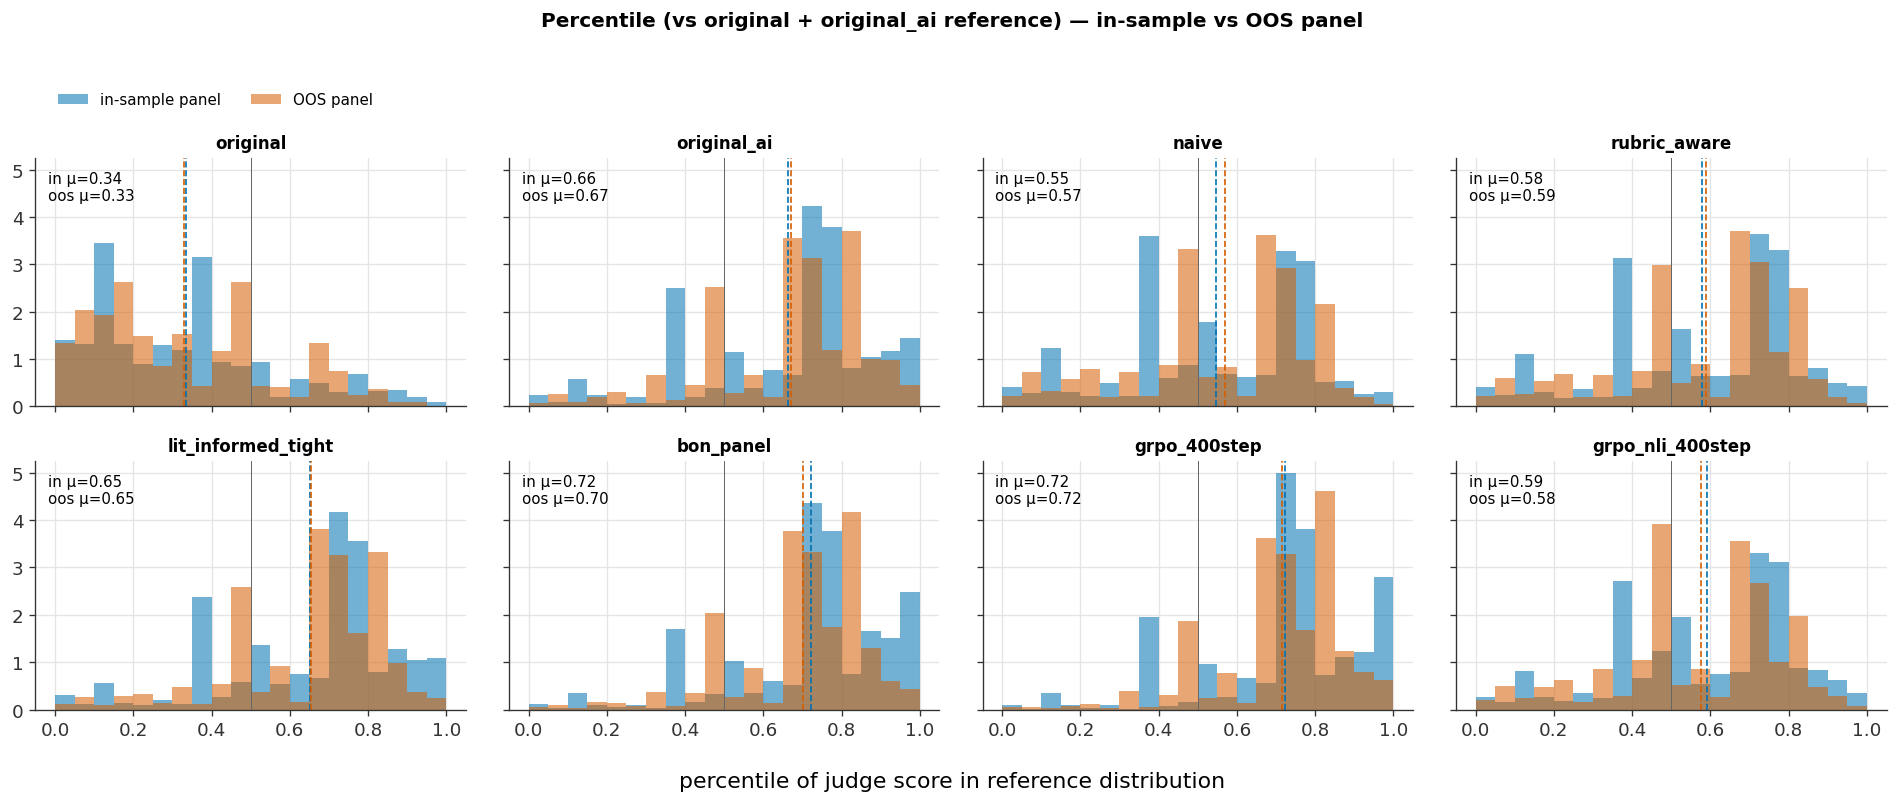

In [36]:
# Histogram of percentile scores per method, in-sample vs OOS panel overlay.
_methods_plot = S8_PCT_METHOD_ORDER
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), sharex=True, sharey=True)
BINS_PCT = np.linspace(0, 1, 21)
for ax, m in zip(axes.flat, _methods_plot):
    d = s8_pct[s8_pct['method'] == m]
    p_in = d.loc[d.panel == 'in_sample', 'pct_full'].to_numpy()
    p_oo = d.loc[d.panel == 'oos',       'pct_full'].to_numpy()
    if len(p_in) == 0 and len(p_oo) == 0:
        ax.set_axis_off(); continue
    if len(p_in):
        ax.hist(p_in, bins=BINS_PCT, density=True, alpha=0.55,
                color=OKABE_ITO['blue'], label='in-sample panel')
        ax.axvline(p_in.mean(), color=OKABE_ITO['blue'], ls='--', lw=1)
    if len(p_oo):
        ax.hist(p_oo, bins=BINS_PCT, density=True, alpha=0.55,
                color=OKABE_ITO['vermilion'], label='OOS panel')
        ax.axvline(p_oo.mean(), color=OKABE_ITO['vermilion'], ls='--', lw=1)
    txt = []
    if len(p_in): txt.append(f'in μ={p_in.mean():.2f}')
    if len(p_oo): txt.append(f'oos μ={p_oo.mean():.2f}')
    ax.text(0.03, 0.95, '\n'.join(txt), transform=ax.transAxes, ha='left', va='top', fontsize=9)
    ax.set_title(m, fontsize=10)
    ax.axvline(0.5, color='#666', lw=0.6)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.02, 1.32), ncol=2,
                  frameon=False, fontsize=9)
fig.suptitle('Percentile (vs original + original_ai reference) — in-sample vs OOS panel',
             y=1.01, fontsize=12, fontweight='semibold')
fig.supxlabel('percentile of judge score in reference distribution')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_s8_8_percentile_in_vs_oos.png')
plt.show()

### 8.8.4 — Reference coverage check

Raw-score distributions per (judge × criterion) for the three populations the percentile
normaliser maps between: **human originals**, **AI originals**, **rewrites**. Reading these
flags pathologies that hide in percentile space:

- if AI scores cluster at 100 → rewrite percentile-vs-AI saturates at 0.5 (everything
  ties with the reference top); discriminating power vanishes
- if rewrites consistently outscore AI → rewrites sit in a region the AI reference doesn't cover
- if human and AI don't overlap → the combined reference is bimodal and "vs full" mixes apples and oranges

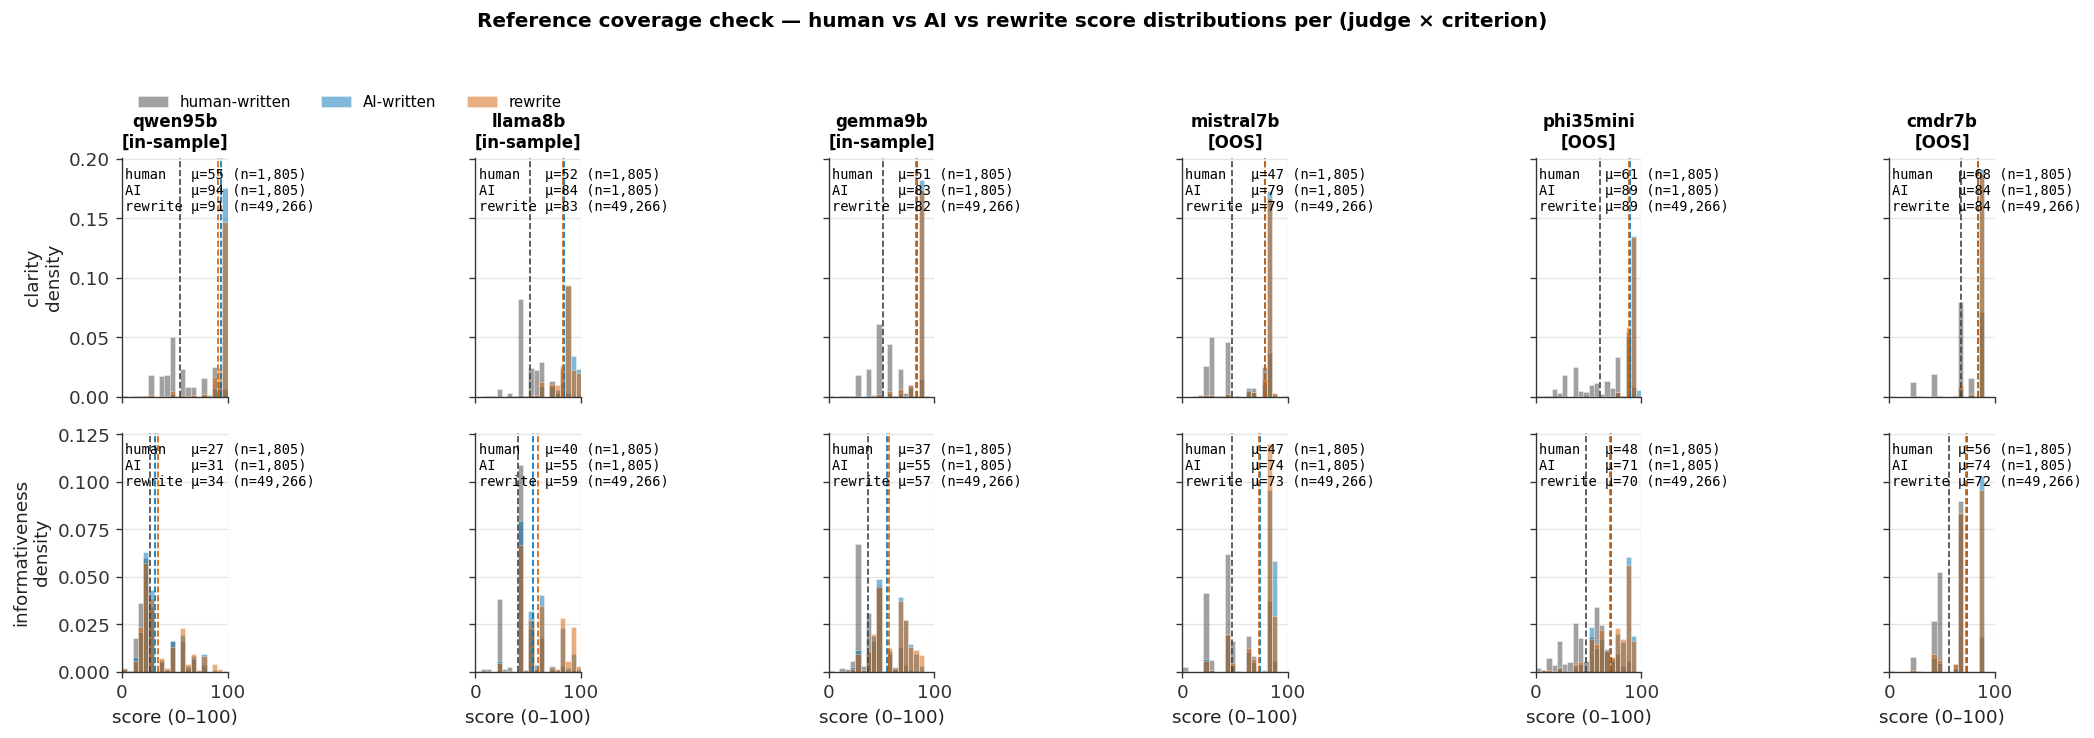

In [37]:
# Pull rewrite scores for in-scope methods, plus original + original_ai, all attack-track judges.
_cov_methods_sql = ','.join(repr(m) for m in S8_METHOD_ORDER + ['original_ai'])
s8_cov = pd.read_sql_query(f'''
    SELECT ar.method, j.judge_slug, j.criterion, j.score
    FROM attack_rewrites ar JOIN attack_judge_scores j ON j.rewrite_id = ar.rewrite_id
    WHERE ar.method IN ({_cov_methods_sql})
      AND j.judge_slug IN ({_all_judges_sql})''', conn)
s8_cov['kind'] = np.where(s8_cov['method'] == 'original',    'human-written',
                  np.where(s8_cov['method'] == 'original_ai', 'AI-written', 'rewrite'))

_KIND_COLOR = {'human-written': '#444444',
               'AI-written':    OKABE_ITO['blue'],
               'rewrite':       OKABE_ITO['vermilion']}
_JUDGE_ORDER = S8_IN_SAMPLE_JUDGES + S8_OOS_JUDGES
_CRITERIA    = ['clarity', 'informativeness']
_BINS = np.arange(0, 105, 5)

fig, axes = plt.subplots(len(_CRITERIA), len(_JUDGE_ORDER), figsize=(17, 6.0),
                         sharex=True, sharey='row')
for i, crit in enumerate(_CRITERIA):
    for j, judge in enumerate(_JUDGE_ORDER):
        ax = axes[i, j]
        d = s8_cov[(s8_cov['criterion'] == crit) & (s8_cov['judge_slug'] == judge)]
        means = {}
        for kind in ['human-written', 'AI-written', 'rewrite']:
            arr = d.loc[d['kind'] == kind, 'score'].to_numpy()
            if len(arr) == 0:
                continue
            ax.hist(arr, bins=_BINS, density=True, color=_KIND_COLOR[kind], alpha=0.50,
                    edgecolor='white', linewidth=0.4, label=kind)
            ax.axvline(arr.mean(), color=_KIND_COLOR[kind], linestyle='--', linewidth=1.0)
            means[kind] = (arr.mean(), len(arr))
        txt = '\n'.join(f'{k.split("-")[0]:<7s} μ={m:.0f} (n={n:,})'
                         for k, (m, n) in means.items())
        ax.text(0.03, 0.96, txt, transform=ax.transAxes, ha='left', va='top',
                fontsize=8.2, family='monospace')
        if i == 0:
            tag = 'in-sample' if judge in S8_IN_SAMPLE_JUDGES else 'OOS'
            ax.set_title(f"{judge.replace('judge_', '')}\n[{tag}]", fontsize=10)
        if i == len(_CRITERIA) - 1: ax.set_xlabel('score (0–100)')
        if j == 0: ax.set_ylabel(f'{crit}\ndensity')
        ax.set_xlim(0, 100)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.02, 1.32), ncol=3,
                  frameon=False, fontsize=9)
fig.suptitle('Reference coverage check — human vs AI vs rewrite score distributions per (judge × criterion)',
             y=1.02, fontsize=12, fontweight='semibold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_s8_8_reference_coverage.png')
plt.show()

In [38]:
# Saturation table: % of reference paragraphs at the maximum score (=100). When this is high,
# percentile-normalisation loses resolution at the top end.
_sat = (s8_cov.groupby(['judge_slug', 'criterion', 'kind'])['score']
        .apply(lambda s: 100 * (s == 100).mean()).unstack('kind').round(1))
print('% of paragraphs at score=100 (saturation indicator):')
display(_sat)

# Range coverage: do rewrite scores ever exceed the max of the AI / human reference?
print('\nMax score by population — does rewrite exceed the reference max anywhere?')
_maxes = s8_cov.groupby(['judge_slug','criterion','kind'])['score'].max().unstack('kind')
display(_maxes)

% of paragraphs at score=100 (saturation indicator):


kind                             AI-written  human-written  rewrite
judge_slug      criterion                                          
judge_cmdr7b    clarity                 0.0            0.0      0.0
                informativeness         0.0            0.0      0.0
judge_gemma9b   clarity                 0.0            0.0      0.0
                informativeness         0.0            0.0      0.0
judge_llama8b   clarity                 0.0            0.0      0.0
                informativeness         0.0            0.0      0.0
judge_mistral7b clarity                 0.2            0.0      0.3
                informativeness         0.0            0.0      0.0
judge_phi35mini clarity                 0.0            0.0      0.0
                informativeness         0.0            0.0      0.0
judge_qwen95b   clarity                13.9            0.3      3.6
                informativeness         0.0            0.0      0.0


Max score by population — does rewrite exceed the reference max anywhere?


kind                             AI-written  human-written  rewrite
judge_slug      criterion                                          
judge_cmdr7b    clarity                85.0           85.0     85.0
                informativeness        85.0           85.0     85.0
judge_gemma9b   clarity                90.0           85.0     90.0
                informativeness        85.0           75.0     90.0
judge_llama8b   clarity                95.0           95.0     95.0
                informativeness        95.0           92.0     95.0
judge_mistral7b clarity               100.0           85.0    100.0
                informativeness        85.0           85.0     85.0
judge_phi35mini clarity                95.0           95.0     95.0
                informativeness        92.0           92.0     95.0
judge_qwen95b   clarity               100.0          100.0    100.0
                informativeness        85.0           75.0     95.0

## 8.9 — BoN-NLI-filter counterfactual

`bon_candidate` (the K=16 pre-selection pool) now has full NLI coverage. We can simulate
"BoN with an NLI floor": within each (source × rewriter × criterion × fold) cell, drop
candidates with `mean_nli < t`, then pick the survivor with the highest mean of the
two in-panel judges' scores (the canonical BoN rule).

The simulator validates against the canonical `bon_panel` selection at t=0
(should match ~95–100%; mismatches are tied-score ambiguities).

In [39]:
S8_BON_THRESHOLDS = [0.0, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
S8_IN_PANEL_BY_FOLD = {1: {'judge_qwen95b','judge_llama8b'},
                       2: {'judge_qwen95b','judge_gemma9b'},
                       3: {'judge_llama8b','judge_gemma9b'}}
S8_HELD_OUT_BY_FOLD = {1: 'judge_gemma9b', 2: 'judge_llama8b', 3: 'judge_qwen95b'}

# Long-format candidate table (one row per candidate, with all 3 in-sample judges as columns).
s8_cand = pd.read_sql_query('''
    SELECT ar.rewrite_id, ar.source_doc_id, ar.rewriter_model,
           ar.criterion AS rew_criterion,
           n.nli_fwd, n.nli_bwd, a.score AS agreement
    FROM attack_rewrites ar
    JOIN attack_nli_scores n        ON n.rewrite_id = ar.rewrite_id
    JOIN attack_agreement_scores a  ON a.rewrite_id = ar.rewrite_id
    WHERE ar.method = 'bon_candidate' ''', conn)
s8_cand['mean_nli'] = (s8_cand['nli_fwd'] + s8_cand['nli_bwd']) / 2.0

for _j in ['judge_qwen95b', 'judge_llama8b', 'judge_gemma9b']:
    _q = pd.read_sql_query(f'''
        SELECT ar.rewrite_id, j.score AS s_{_j}
        FROM attack_rewrites ar
        JOIN attack_judge_scores j ON j.rewrite_id=ar.rewrite_id AND j.criterion=ar.criterion
        WHERE ar.method='bon_candidate' AND j.judge_slug=\'{_j}\' ''', conn)
    s8_cand = s8_cand.merge(_q, on='rewrite_id', how='left')
s8_cand.columns.name = None

print(f'candidates: {len(s8_cand):,}   K per cell: {s8_cand.groupby(["source_doc_id","rewriter_model","rew_criterion"]).size().mean():.1f}')

def s8_simulate_bon(threshold):
    g = s8_cand if threshold == 0.0 else s8_cand[s8_cand['mean_nli'] >= threshold].copy()
    out = []
    for fold, panel in S8_IN_PANEL_BY_FOLD.items():
        held_out_col = f's_{S8_HELD_OUT_BY_FOLD[fold]}'
        panel_cols   = [f's_{j}' for j in panel]
        gg = g.copy()
        gg['panel_mean'] = gg[panel_cols].mean(axis=1)
        idx = gg.groupby(['source_doc_id', 'rewriter_model', 'rew_criterion'])['panel_mean'].idxmax()
        sel = gg.loc[idx].copy()
        sel['fold'] = fold
        sel['held_out_score'] = sel[held_out_col]
        out.append(sel[['rewrite_id', 'source_doc_id', 'rewriter_model', 'rew_criterion', 'fold',
                        'mean_nli', 'agreement', 'panel_mean', 'held_out_score']])
    return pd.concat(out, ignore_index=True)

# Validate sim at t=0 reproduces canonical bon_panel selections.
_canon = pd.read_sql_query('''
    SELECT ar.source_doc_id, ar.rewriter_model, ar.criterion AS rew_criterion, ar.fold,
           json_extract(ar.config_json, '$.selected_candidate_rid') AS sel_rid
    FROM attack_rewrites ar WHERE ar.method='bon_panel' ''', conn)
_sim0 = s8_simulate_bon(0.0)
_chk = _canon.merge(_sim0, on=['source_doc_id', 'rewriter_model', 'rew_criterion', 'fold'])
print(f'reproducibility @ t=0:  {(_chk.sel_rid == _chk.rewrite_id).sum():,}/{len(_chk):,} '
      f'({100 * (_chk.sel_rid == _chk.rewrite_id).mean():.2f}%)  — '
      f'mismatches are tied-best ambiguities.')

candidates: 68,544   K per cell: 16.0
reproducibility @ t=0:  12,220/12,852 (95.08%)  — mismatches are tied-best ambiguities.


In [40]:
# Threshold sweep: outcomes table.
_orig_a = pd.read_sql_query('''
    SELECT ar.source_doc_id, AVG(a.score) AS orig_agree
    FROM attack_rewrites ar JOIN attack_agreement_scores a ON a.rewrite_id=ar.rewrite_id
    WHERE ar.method='original' GROUP BY ar.source_doc_id''', conn)

S8_TOTAL_BON_CELLS = 714 * 3 * 2 * 3   # source × rewriter × criterion × fold

_out = []
for _t in S8_BON_THRESHOLDS:
    sim = s8_simulate_bon(_t)
    _eff_K = (s8_cand.assign(_p=(s8_cand['mean_nli'] >= _t).astype(int))
                     .groupby(['source_doc_id', 'rewriter_model', 'rew_criterion'])['_p']
                     .sum().mean())
    sw = sim.merge(_orig_a, on='source_doc_id')
    keep = sw[(sw.orig_agree <= 0.25) | (sw.orig_agree >= 0.75)]
    n_flip = ((keep.orig_agree <= 0.25) & (keep.agreement >= 0.75)).sum() + \
             ((keep.orig_agree >= 0.75) & (keep.agreement <= 0.25)).sum()
    _out.append({
        't_NLI':         _t,
        'eff_K':         round(_eff_K, 2),
        'cells_no_surv': S8_TOTAL_BON_CELLS - len(sim),
        'panel_mean':    round(sim['panel_mean'].mean(), 2),
        'held_out':      round(sim['held_out_score'].mean(), 2),
        'mean_nli':      round(sim['mean_nli'].mean(), 3),
        'agreement':     round(sim['agreement'].mean(), 3),
        'flip_rate_%':   round(100 * n_flip / len(keep), 2) if len(keep) else float('nan'),
        'n_kept':        int(len(keep)),
    })
s8_bon_sweep = pd.DataFrame(_out)
print('=== Filter-then-reselect threshold sweep ===')
print(s8_bon_sweep.to_string(index=False))

# Cells with 0 survivors per (rewriter, threshold).
_miss = []
for _t in S8_BON_THRESHOLDS:
    surv = (s8_cand.assign(_p=(s8_cand['mean_nli'] >= _t).astype(int))
                    .groupby(['source_doc_id', 'rewriter_model', 'rew_criterion'])['_p']
                    .sum().reset_index())
    _miss.append(pd.Series(
        surv.groupby('rewriter_model')['_p'].apply(lambda x: int((x == 0).sum())),
        name=_t))
s8_bon_misses = pd.DataFrame(_miss).T
s8_bon_misses.columns.name = 'threshold'
s8_bon_misses.index.name   = 'rewriter'
print('\n=== Cells with 0 survivors (out of 4,284 per rewriter) ===')
print(s8_bon_misses.to_string())

=== Filter-then-reselect threshold sweep ===
 t_NLI  eff_K  cells_no_surv  panel_mean  held_out  mean_nli  agreement  flip_rate_%  n_kept
  0.00  16.00              0       80.55     75.16     0.364      0.752        21.26    9252
  0.50   5.98           2982       74.14     70.36     0.694      0.660         2.68    7200
  0.60   4.27           4821       73.27     69.89     0.795      0.646         2.05    5946
  0.70   3.43           5772       72.77     69.51     0.857      0.634         1.43    5250
  0.75   3.05           6267       72.42     69.06     0.884      0.630         1.18    4905
  0.80   2.68           6630       71.87     68.80     0.907      0.624         1.12    4656
  0.85   2.29           7104       71.31     68.52     0.928      0.620         0.86    4296
  0.90   1.80           7761       70.57     68.03     0.949      0.616         0.71    3813

=== Cells with 0 survivors (out of 4,284 per rewriter) ===
threshold                      0.00  0.50  0.60  0.70  0.7

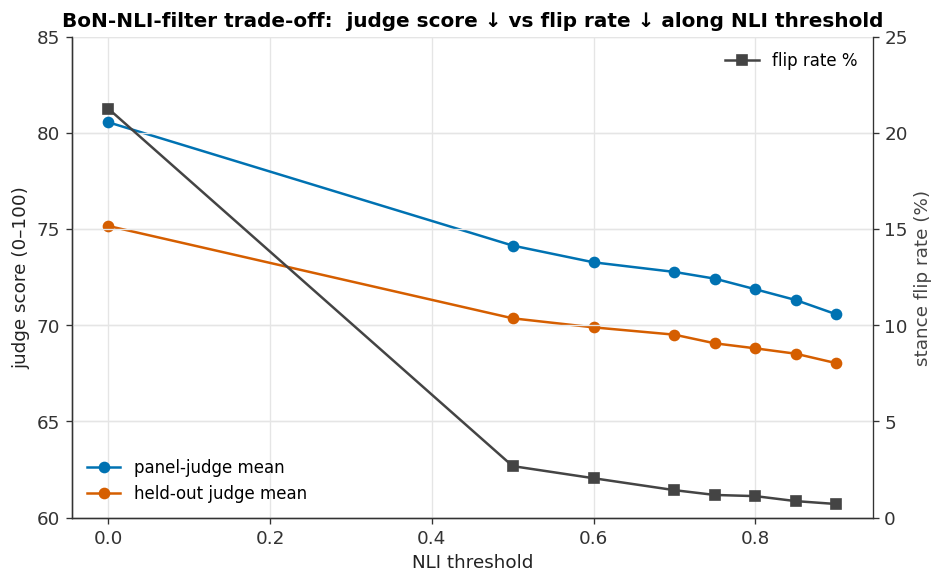

In [41]:
# Trade-off plot: judge-score sacrifice vs flip-rate reduction along the threshold axis.
fig, ax = plt.subplots(figsize=(8, 5))
xs = s8_bon_sweep['t_NLI'].to_numpy()
ax.plot(xs, s8_bon_sweep['panel_mean'],   '-o', color=OKABE_ITO['blue'],     label='panel-judge mean')
ax.plot(xs, s8_bon_sweep['held_out'],     '-o', color=OKABE_ITO['vermilion'],label='held-out judge mean')
ax.set_xlabel('NLI threshold')
ax.set_ylabel('judge score (0–100)')
ax.set_ylim(60, 85)
ax.legend(loc='lower left', frameon=False)
ax2 = ax.twinx()
ax2.plot(xs, s8_bon_sweep['flip_rate_%'], '-s', color='#444', label='flip rate %')
ax2.set_ylabel('stance flip rate (%)', color='#444')
ax2.set_ylim(0, 25)
ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)
ax2.legend(loc='upper right', frameon=False)
ax.set_title('BoN-NLI-filter trade-off:  judge score ↓ vs flip rate ↓ along NLI threshold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_s8_9_bon_nli_tradeoff.png')
plt.show()

In [42]:
conn.close()